# Civil Litigation Outcome Prediction Model — v5.0

# by: Alex Osterneck, CLA, MSCS, MSIT
# (c) AI70000, Ltd.

## Complete Codebase · Schema · Neural Network · Weighted Prediction Engine

### Consumer Banking Litigation · FJC Dataset · Binary Classification

Self-contained single-file prediction system:

1. **Schema & Constants** — FJC variable definitions, NOS/circuit/origin/disposition maps, doctrinal eras
2. **Real FJC Dataset** — 10,000+ resolved federal cases (2020–2025)
3. **TensorFlow/Keras Neural Network** — Binary classifier (32→128→64→32→1 sigmoid)
4. **Weighted Prediction Engine** — Full Python port of the TypeScript engine with seminal-case analysis
5. **Interactive Prediction** — Run both models and compare
6. **Evaluation & Metrics** — AUC, precision, recall, confusion matrix, per-feature analysis

---

### 8 FJC Predictor Variables

| # | Variable | FJC Field | Encoding |
|---|----------|-----------|----------|
| 1 | NOS Code | NOS | One-hot (4 codes: 480, 190, 371, 370) |
| 2 | Origin Code | ORIGIN | One-hot (8 categories) |
| 3 | Class Action | CLASSACT | Binary (-8 = no, 1 = yes) |
| 4 | Circuit Code | CIRCUIT | One-hot (12 circuits: 0=DC, 1-11) |
| 5 | Year Filed | FILEDATE | Normalized continuous |
| 6 | Arbitration | ARBIT | Binary (-8 = no, E/V/M/Y = yes) |
| 7 | MDL Status | MDLDOCK | Binary (-8 = no, numeric = yes) |
| 8 | Doctrinal Era | Derived from Year | One-hot (4 eras) |

### Binary Outcome (Target) — Adjudicated Cases Only

| Label | FJC Field | Description |
|-------|-----------|-------------|
| 1 (Plaintiff-favorable) | JUDGMENT == 1 | Court-entered judgment for plaintiff — adjudicated outcome only |
| 0 (Not plaintiff-favorable) | JUDGMENT ≠ 1 | Defendant judgment, dismissal, or no court ruling entered |






Scope and Architecture — v5.0 Multi-Head Model with Heckman Correction
This model operates across two populations simultaneously.

Primary Adjudication Head (JUDGMENT == 1): Predicts the probability of a court-entered judgment for the plaintiff in the 14% of cases that reach adjudication. The target variable is FJC JUDGMENT == 1 — the only unambiguous ground-truth indicator of an adjudicated plaintiff win. Cases coded JUDGMENT == 0 (settlements, voluntary dismissals, procedural transfers) are excluded from the positive class not because they are defendant-favorable, but because the court never ruled. Settlement terms and economic outcomes are not captured in the FJC IDB.

PROPRIETARY TO AI70000, LTD:

1) Settlement Pressure Head (Heckman Correction): Models the 86% of cases that terminate without adjudication using time-to-disposition (FILEDATE → TERMDATE delta) and procedural stage at termination (PROCSTAT_ORD) as proxies for defendant risk exposure.

2) The Heckman Two-Step correction addresses the fundamental selection bias problem: adjudicated cases are not a random sample of all filed cases. The strongest plaintiff cases are disproportionately concentrated in the settlement population because defendants settle precisely to avoid adverse court rulings. By weighting adjudicated training cases inversely to their probability of settlement, the model corrects for this bias.

3) Blended Risk/Value Output: The combined output — Settlement Probability × Adjudicated Strength — produces a unified Risk/Value score across all possible outcomes. The weighted doctrinal engine incorporates case-specific factors (concrete injury, regulatory admission, defendant risk profile) not captured in FJC structural variables.

4) This model should be interpreted as: "given the full structural and case-specific profile of this matter, what is the probability distribution across adjudication, high-value settlement, nuisance settlement, and dismissal — and what is the defendant's exposure at each outcome."









### Doctrinal Eras (Seminal Cases)

| Era | Period | Key Case |
|-----|--------|----------|
| Pre-Concepcion | Before 2011 | AT&T v. Concepcion |
| Post-Concepcion | 2011–2016 | Arbitration enforcement |
| Post-Spokeo | 2016–2021 | Spokeo v. Robins (standing) |
| Post-TransUnion | 2021–present | TransUnion v. Ramirez |

### Supplemental Variables (Weighted Engine Only)

| Variable | Source |
|----------|--------|
| Concrete Injury Documented | Spokeo/TransUnion standing analysis |
| Prior Regulatory Action | CashCall/CFPB enforcement |
| Defendant Bank | Institutional risk profile |

---
## Part 1: Dependencies & Environment

In [1]:
"""Part 1 — Import all dependencies and configure global plot settings."""

import json
import os
import uuid
from datetime import datetime
from typing import Dict, List, Optional, Tuple

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TF C++ info/warning logs.

import matplotlib
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from tensorflow import keras
from tensorflow.keras import Model, callbacks, layers

# ── Global plot style ────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

print(f'TensorFlow: {tf.__version__}  NumPy: {np.__version__}  Pandas: {pd.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')


TensorFlow: 2.19.0  NumPy: 2.0.2  Pandas: 2.2.2
GPU available: False


---
## Part 2: Complete Schema — FJC Variable Definitions & Constants

Python equivalent of `shared/schema.ts`.  
Every constant, code mapping, and dimension used across the system is defined here.

In [2]:
"""Part 2 — FJC schema constants: NOS, origin, circuit, disposition, doctrinal eras."""

# ── NOS code label map (all federal civil categories) ───────────────────────
NOS_CODE_LABELS: Dict[str, str] = {
    '110': 'Insurance', '120': 'Marine', '130': 'Miller Act', '140': 'Negotiable Instrument',
    '150': 'Recovery of Overpayment', '151': 'Medicare Act', '152': 'Recovery of Student Loans',
    '153': 'Recovery of Veteran Benefits', '160': "Stockholders' Suits", '190': 'Other Contract',
    '195': 'Contract Product Liability', '196': 'Franchise', '210': 'Land Condemnation',
    '220': 'Foreclosure', '230': 'Rent Lease & Ejectment', '240': 'Torts to Land',
    '245': 'Tort Product Liability', '290': 'All Other Real Property', '310': 'Airplane',
    '315': 'Airplane Product Liability', '320': 'Assault, Libel & Slander',
    '330': "Fed Employers' Liability", '340': 'Marine', '345': 'Marine Product Liability',
    '350': 'Motor Vehicle', '355': 'Motor Vehicle Product Liability',
    '360': 'Other Personal Injury', '362': 'Personal Injury - Medical Malpractice',
    '365': 'Personal Injury - Product Liability', '367': 'Health Care/Pharmaceutical',
    '368': 'Asbestos Personal Injury', '370': 'Other Fraud', '371': 'Truth in Lending',
    '375': 'False Claims Act', '376': 'Qui Tam (31 USC 3729a)',
    '380': 'Other Personal Property Damage', '385': 'Property Damage Product Liability',
    '400': 'State Reapportionment', '410': 'Antitrust',
    '422': 'Bankruptcy Appeals (28 USC 158)', '423': 'Withdrawal 28 USC 157',
    '430': 'Banks and Banking', '440': 'Other Civil Rights', '441': 'Voting',
    '442': 'Employment', '443': 'Housing/Accommodations', '444': 'Welfare',
    '445': 'Americans with Disabilities (Employment)',
    '446': 'Americans with Disabilities (Other)', '448': 'Education', '450': 'Commerce',
    '460': 'Deportation', '462': 'Naturalization Application',
    '463': 'Habeas Corpus - Alien Detainee', '465': 'Other Immigration Actions',
    '470': 'RICO', '480': 'Consumer Credit', '490': 'Cable/Sat TV',
    '510': 'Motions to Vacate Sentence', '530': 'General', '535': 'Death Penalty',
    '540': 'Mandamus & Other', '550': 'Civil Rights', '555': 'Prison Condition',
    '560': 'Civil Detainee', '610': 'Agricultural Acts', '620': 'Other Food & Drug',
    '625': 'Drug Related Seizure of Property', '630': 'Liquor Laws',
    '640': 'Railroad & Trucks', '650': 'Airline Regulations',
    '660': 'Occupational Safety/Health', '690': 'Other',
    '710': 'Fair Labor Standards Act', '720': 'Labor/Management Relations',
    '730': 'Labor/Management Reporting & Disclosure Act', '740': 'Railway Labor Act',
    '751': 'Family and Medical Leave Act', '790': 'Other Labor Litigation',
    '791': 'ERISA', '810': 'Selective Service', '820': 'Copyrights', '830': 'Patent',
    '835': 'Patent - Abbreviated New Drug Application', '840': 'Trademark',
    '850': 'Securities/Commodities/Exchange', '860': 'Social Security',
    '861': 'HIA (1395ff)', '862': 'Black Lung (923)', '863': 'DIWC/DIWW (405g)',
    '864': 'SSID (Title XVI)', '865': 'RSI (405g)',
    '870': 'Taxes (US Plaintiff or Defendant)', '871': 'IRS - Third Party',
    '875': 'Customer Challenge 12 USC 3410', '890': 'Other Statutory Actions',
    '891': 'Agricultural Acts', '893': 'Environmental Matters',
    '895': 'Freedom of Information Act', '896': 'Arbitration',
    '899': 'Administrative Procedure Act/Review or Appeal of Agency Decision',
    '900': 'Appeal of Fee Determination Under Equal Access to Justice',
    '910': 'Domestic Relations', '920': 'Insanity', '930': 'Probate',
    '940': 'Substitute Trustee', '950': 'Constitutionality of State Statutes',
}

# ── Consumer-banking NOS subset used as NN features ─────────────────────────
CONSUMER_BANKING_NOS_CODES: List[str] = ['480', '190', '371', '370']

NOS_CODE_DESCRIPTIONS: Dict[str, str] = {
    '480': 'Consumer Credit (FCRA, FDCPA, EFTA, ECOA)',
    '190': 'Banks and Banking (Other Contract)',
    '371': 'Truth in Lending (TILA/Reg Z)',
    '370': 'Other Fraud (UDAAP, deceptive practices)',
}

# ── Origin, circuit, disposition maps ───────────────────────────────────────
ORIGIN_CODES: List[str] = ['1', '2', '3', '4', '5', '6', '7', '8']

ORIGIN_CODE_LABELS: Dict[str, str] = {
    '1': 'Original Proceeding',
    '2': 'Removed from State Court',
    '3': 'Remanded from Appellate Court',
    '4': 'Reinstated or Reopened',
    '5': 'Transferred from Another District',
    '6': 'Multidistrict Litigation (MDL)',
    '7': 'Appeal to District Judge of Magistrate Judge Decision',
    '8': 'Multi-district Litigation (Originating)',
}

CIRCUIT_CODES: List[str] = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']

CIRCUIT_CODE_LABELS: Dict[str, str] = {
    '0': 'D.C. Circuit', '1': '1st Circuit', '2': '2nd Circuit', '3': '3rd Circuit',
    '4': '4th Circuit', '5': '5th Circuit', '6': '6th Circuit', '7': '7th Circuit',
    '8': '8th Circuit', '9': '9th Circuit', '10': '10th Circuit', '11': '11th Circuit',
    'DC': 'D.C. Circuit',
}

DISPOSITION_CODE_LABELS: Dict[str, str] = {
    '0': 'Transfer to another district', '1': 'Remanded to state court',
    '2': 'Dismissed — want of prosecution', '3': 'Dismissed — lack of jurisdiction',
    '4': 'Judgment on default', '5': 'Judgment on consent',
    '6': 'Judgment on motion before trial', '7': 'Judgment on jury verdict',
    '8': 'Judgment on directed verdict', '9': 'Judgment on court trial',
    '10': 'Multi-district litigation transfer', '11': 'Remanded to U.S. Agency',
    '12': 'Voluntarily dismissed', '13': 'Settled', '14': 'Other',
    '15': 'Judgment for plaintiff (statistical closing)',
    '16': 'Judgment for defendant (statistical closing)',
    '17': 'Dismissed for want of prosecution (statistical closing)',
    '18': 'Dismissed — other (statistical closing)',
    '19': 'Transfer (statistical closing)', '20': 'Consolidation (statistical closing)',
}

# ── Plaintiff-favorable disposition codes (binary target = 1) ───────────────
# ── Plaintiff-favorable target: JUDGMENT == 1 (ground truth) ────────────────
# DISP codes excluded as target variable: procedural mechanism does not reliably
# indicate winner. DISP 6 is 72% defendant wins. DISP 13 (Settled) has no
# visibility into settlement terms. JUDGMENT == 1 is the FJC ground-truth field
# for plaintiff wins — the only unambiguous adjudicated outcome indicator.
PLAINTIFF_FAVORABLE_JUDGMENT: float = 1.0   # FJC JUDGMENT code for plaintiff win
PLAINTIFF_FAVORABLE_LABEL: str = 'Judgment for Plaintiff (JUDGMENT == 1)'

# Retained for schema reference and Part 17 DISP distribution reporting only.
# Not used as training target.
FJC_DISPOSITION_MAP: Dict[str, str] = {
    '4': 'judgment-on-default', '5': 'judgment-on-consent',
    '6': 'judgment-on-motion-before-trial', '7': 'judgment-on-jury-verdict',
    '8': 'judgment-on-directed-verdict', '9': 'judgment-on-court-trial',
    '15': 'judgment-for-plaintiff-statistical',
}
PLAINTIFF_FAVORABLE_DISP: List[float] = []   # Deprecated — not used as target
PLAINTIFF_FAVORABLE_LABELS: Dict[str, str] = {}  # Deprecated — not used as target

# ── Doctrinal eras derived from FILEDATE year ────────────────────────────────
DOCTRINAL_ERAS: List[str] = [
    'pre-concepcion',
    'post-concepcion-pre-spokeo',
    'post-spokeo-pre-transunion',
    'post-transunion',
]
DOCTRINAL_ERA_LABELS: Dict[str, str] = {
    'pre-concepcion':              'Pre-Concepcion (before 2011)',
    'post-concepcion-pre-spokeo':  'Post-Concepcion / Pre-Spokeo (2011–2016)',
    'post-spokeo-pre-transunion':  'Post-Spokeo / Pre-TransUnion (2016–2021)',
    'post-transunion':             'Post-TransUnion (2021–present)',
}
ERA_NAMES: List[str] = ['Pre-Concepcion', 'Post-Concepcion', 'Post-Spokeo', 'Post-TransUnion']

# ── Defendant bank roster (weighted engine risk profiles) ───────────────────
MAJOR_BANKS: List[str] = [
    'JPMorgan Chase', 'Bank of America', 'Wells Fargo', 'Citibank', 'Capital One',
    'U.S. Bank', 'PNC Financial', 'TD Bank', 'Truist', 'Goldman Sachs',
    'Morgan Stanley', 'Ally Financial', 'Discover', 'Synchrony Financial',
    'CashCall / Western Sky', 'Other',
]


# ── Utility functions ────────────────────────────────────────────────────────
def get_doctrinal_era(year) -> int:
    """Return 0-3 era index for a given filing year. Returns 0 for None/invalid."""
    if year is None or (isinstance(year, float) and pd.isna(year)):
        return 0
    year = int(year)
    if year < 2011:
        return 0
    if year < 2016:
        return 1
    if year < 2021:
        return 2
    return 3


def get_doctrinal_era_name(year: int) -> str:
    """Return the DOCTRINAL_ERAS string for a filing year."""
    return DOCTRINAL_ERAS[get_doctrinal_era(year)]


def is_removed_from_state_court(origin: str) -> bool:
    """Return True when ORIGIN code indicates removal from state court."""
    return str(origin) == '2'


def is_mdl_origin(origin: str) -> bool:
    """Return True when ORIGIN code indicates MDL origin (codes 6 or 8)."""
    return str(origin) in ('6', '8')


# ── Feature-vector dimension constants ──────────────────────────────────────
N_NOS          = len(CONSUMER_BANKING_NOS_CODES)  # 4
N_ORIGIN       = len(ORIGIN_CODES)                # 8
N_CIRCUIT      = len(CIRCUIT_CODES)               # 12
N_CLASS_ACTION = 1
N_ARBIT        = 1
N_MDL          = 1
N_YEAR         = 1
N_ERA          = 4

INPUT_DIM  = N_NOS + N_ORIGIN + N_CIRCUIT + N_CLASS_ACTION + N_ARBIT + N_MDL + N_YEAR + N_ERA
OUTPUT_DIM = 1

print('=== SCHEMA LOADED ===')
print(f'NOS codes  : {CONSUMER_BANKING_NOS_CODES}')
print(f'Circuits   : {CIRCUIT_CODES}')
print(f'PF DISP    : {PLAINTIFF_FAVORABLE_DISP}')
print(f'Eras       : {ERA_NAMES}')
print(f'Banks      : {len(MAJOR_BANKS)}')
print(f'INPUT_DIM  : {INPUT_DIM}  '
      f'(NOS={N_NOS} ORIGIN={N_ORIGIN} CIRCUIT={N_CIRCUIT} '
      f'CLASSACT={N_CLASS_ACTION} ARBIT={N_ARBIT} MDL={N_MDL} YEAR={N_YEAR} ERA={N_ERA})')
print(f'OUTPUT_DIM : {OUTPUT_DIM} (binary sigmoid)')


=== SCHEMA LOADED ===
NOS codes  : ['480', '190', '371', '370']
Circuits   : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
PF DISP    : []
Eras       : ['Pre-Concepcion', 'Post-Concepcion', 'Post-Spokeo', 'Post-TransUnion']
Banks      : 16
INPUT_DIM  : 32  (NOS=4 ORIGIN=8 CIRCUIT=12 CLASSACT=1 ARBIT=1 MDL=1 YEAR=1 ERA=4)
OUTPUT_DIM : 1 (binary sigmoid)


### Schema Visual: Feature Encoding Pipeline

How raw FJC fields are transformed into the 32-dimensional neural network input vector.

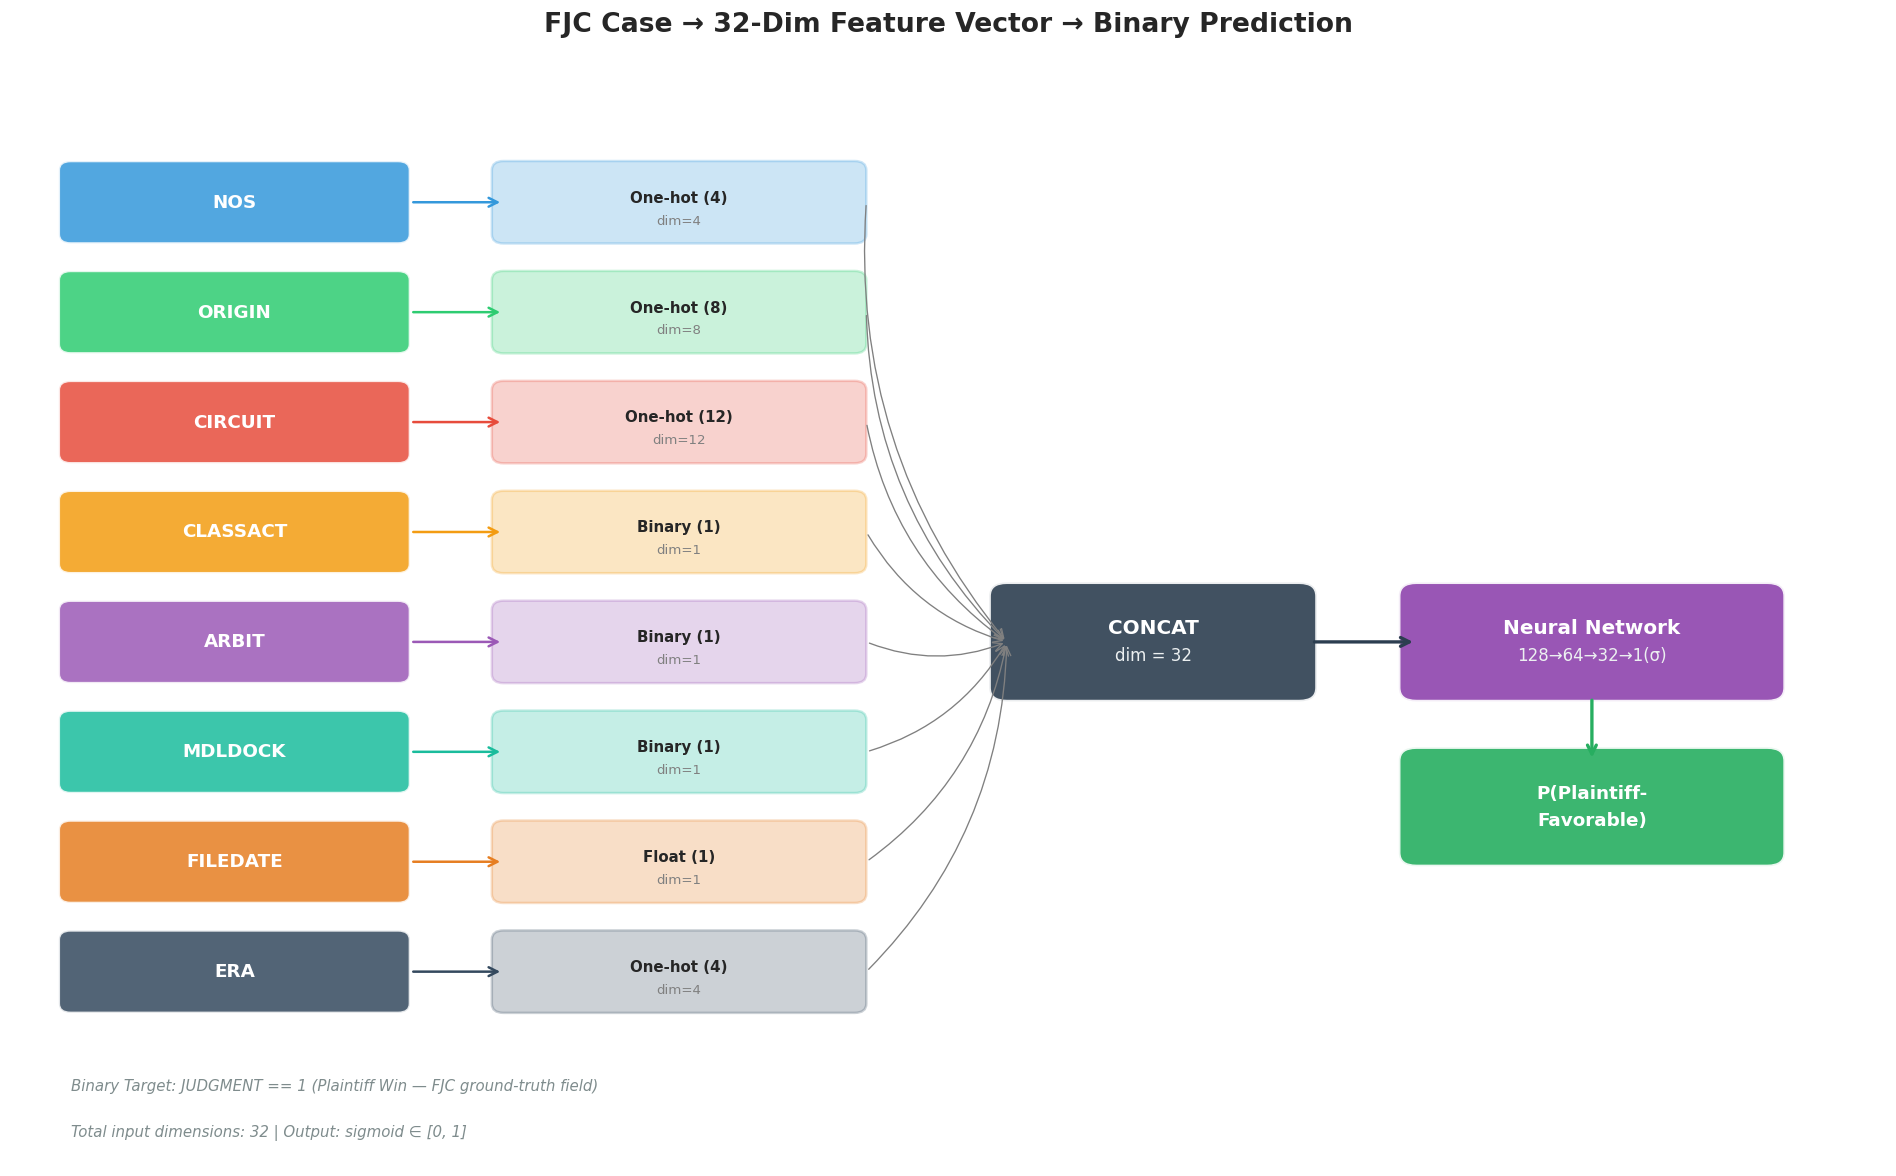

Schema pipeline visualization saved.


In [3]:
"""Part 2 (continued) — Visualize the FJC field → feature-vector encoding pipeline."""

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 12)
ax.axis('off')
ax.set_title('FJC Case → 32-Dim Feature Vector → Binary Prediction', fontsize=16, fontweight='bold', pad=20)

raw_fields = [
    ('NOS',     '4 codes\n480, 190, 371, 370'),
    ('ORIGIN',  '8 codes\n1–8'),
    ('CIRCUIT', '12 codes\n0(DC)–11'),
    ('CLASSACT','Binary\n-8 or 1'),
    ('ARBIT',   'Binary\n-8 or E/V/M/Y'),
    ('MDLDOCK', 'Binary\n-8 or numeric'),
    ('FILEDATE','Normalized\nyear'),
    ('ERA',     '4 eras\none-hot'),
]
encodings  = ['One-hot (4)', 'One-hot (8)', 'One-hot (12)', 'Binary (1)', 'Binary (1)', 'Binary (1)', 'Float (1)', 'One-hot (4)']
dims       = [4, 8, 12, 1, 1, 1, 1, 4]
clrs       = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#34495e']

for i, (field, _) in enumerate(raw_fields):
    y = 10.5 - i * 1.2
    ax.add_patch(FancyBboxPatch((0.5, y - 0.35), 2.8, 0.7, boxstyle='round,pad=0.1',
                                 facecolor=clrs[i], alpha=0.85, edgecolor='white', linewidth=1.5))
    ax.text(1.9, y, field, ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    ax.annotate('', xy=(4.2, y), xytext=(3.4, y),
                arrowprops=dict(arrowstyle='->', color=clrs[i], lw=1.5))
    ax.add_patch(FancyBboxPatch((4.2, y - 0.35), 3.0, 0.7, boxstyle='round,pad=0.1',
                                 facecolor=clrs[i], alpha=0.25, edgecolor=clrs[i], linewidth=1.5))
    ax.text(5.7, y + 0.05, encodings[i], ha='center', va='center', fontsize=9, fontweight='bold')
    ax.text(5.7, y - 0.20, f'dim={dims[i]}', ha='center', va='center', fontsize=8, color='gray')

concat_y = 5.7
for i in range(len(raw_fields)):
    y = 10.5 - i * 1.2
    ax.annotate('', xy=(8.5, concat_y), xytext=(7.3, y),
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8, connectionstyle='arc3,rad=0.2'))

ax.add_patch(FancyBboxPatch((8.5, concat_y - 0.5), 2.5, 1.0, boxstyle='round,pad=0.15',
                             facecolor='#2c3e50', alpha=0.9, edgecolor='white', linewidth=2))
ax.text(9.75, concat_y + 0.15, 'CONCAT', ha='center', va='center', fontsize=12, fontweight='bold', color='white')
ax.text(9.75, concat_y - 0.15, f'dim = {sum(dims)}', ha='center', va='center', fontsize=10, color='#ecf0f1')

ax.annotate('', xy=(12.0, concat_y), xytext=(11.1, concat_y),
            arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=2))

ax.add_patch(FancyBboxPatch((12.0, concat_y - 0.5), 3.0, 1.0, boxstyle='round,pad=0.15',
                             facecolor='#8e44ad', alpha=0.9, edgecolor='white', linewidth=2))
ax.text(13.5, concat_y + 0.15, 'Neural Network', ha='center', va='center', fontsize=12, fontweight='bold', color='white')
ax.text(13.5, concat_y - 0.15, '128→64→32→1(σ)', ha='center', va='center', fontsize=10, color='#ecf0f1')

ax.add_patch(FancyBboxPatch((12.0, concat_y - 2.3), 3.0, 1.0, boxstyle='round,pad=0.15',
                             facecolor='#27ae60', alpha=0.9, edgecolor='white', linewidth=2))
ax.annotate('', xy=(13.5, concat_y - 1.3), xytext=(13.5, concat_y - 0.6),
            arrowprops=dict(arrowstyle='->', color='#27ae60', lw=2))
ax.text(13.5, concat_y - 1.65, 'P(Plaintiff-',    ha='center', va='center', fontsize=11, fontweight='bold', color='white')
ax.text(13.5, concat_y - 1.95, 'Favorable)',       ha='center', va='center', fontsize=11, fontweight='bold', color='white')

ax.text(0.5, 0.8, 'Binary Target: JUDGMENT == 1 (Plaintiff Win — FJC ground-truth field)',
        fontsize=9, style='italic', color='#7f8c8d')
ax.text(0.5, 0.3, f'Total input dimensions: {sum(dims)} | Output: sigmoid ∈ [0, 1]',
        fontsize=9, style='italic', color='#7f8c8d')

plt.tight_layout()
plt.savefig('schema_pipeline.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Schema pipeline visualization saved.')


---
## Part 3: Seminal Case Library

Key precedents that shape the weighted prediction engine's doctrinal analysis.

In [4]:
"""Part 3 — Seminal case library: citation, holding, and year for each doctrine anchor."""

SEMINAL_CASES: Dict[str, Dict] = {
    'concepcion': {
        'citation':   'AT&T Mobility LLC v. Concepcion, 563 U.S. 333 (2011)',
        'short_name': 'Concepcion',
        'year':       2011,
        'holding':    'FAA preempts state unconscionability rules that condition arbitration enforcement on class-action availability',
    },
    'cashcall': {
        'citation':   'CFPB v. CashCall, Inc., No. 1:13-cv-13167 (D. Mass. 2016)',
        'short_name': 'CashCall',
        'year':       2016,
        'holding':    'Lending practices violating state law constitute unfair/deceptive acts under UDAAP',
    },
    'overdraft_mdl': {
        'citation':   'In re Checking Account Overdraft Litigation, MDL No. 2036',
        'short_name': 'Overdraft MDL',
        'year':       2009,
        'holding':    'MDL consolidation of consumer banking claims creates aggregate settlement leverage',
    },
    'spokeo': {
        'citation':   'Spokeo, Inc. v. Robins, 578 U.S. 330 (2016)',
        'short_name': 'Spokeo',
        'year':       2016,
        'holding':    'Article III standing requires concrete injury, not merely statutory violation',
    },
    'transunion': {
        'citation':   'TransUnion LLC v. Ramirez, 594 U.S. 413 (2021)',
        'short_name': 'TransUnion',
        'year':       2021,
        'holding':    'Concrete injury must bear close relationship to traditionally recognized harms; each class member needs individual standing',
    },
    'marquette': {
        'citation':   "Marquette Nat'l Bank v. First of Omaha Service Corp., 439 U.S. 299 (1978)",
        'short_name': 'Marquette',
        'year':       1978,
        'holding':    'National banks may export interest rates from home state regardless of borrower state usury limits',
    },
    'beneficial': {
        'citation':   "Beneficial Nat'l Bank v. Anderson, 539 U.S. 1 (2003)",
        'short_name': 'Beneficial',
        'year':       2003,
        'holding':    'Complete preemption under National Bank Act allows removal of state-law usury claims to federal court',
    },
}

print('=== SEMINAL CASE LIBRARY ===')
for case in SEMINAL_CASES.values():
    print(f"  {case['short_name']} ({case['year']}): {case['holding'][:80]}...")


=== SEMINAL CASE LIBRARY ===
  Concepcion (2011): FAA preempts state unconscionability rules that condition arbitration enforcemen...
  CashCall (2016): Lending practices violating state law constitute unfair/deceptive acts under UDA...
  Overdraft MDL (2009): MDL consolidation of consumer banking claims creates aggregate settlement levera...
  Spokeo (2016): Article III standing requires concrete injury, not merely statutory violation...
  TransUnion (2021): Concrete injury must bear close relationship to traditionally recognized harms; ...
  Marquette (1978): National banks may export interest rates from home state regardless of borrower ...
  Beneficial (2003): Complete preemption under National Bank Act allows removal of state-law usury cl...


---
## Part 4: Load Real FJC Dataset

In [5]:
"""Part 4 — Load FJC dataset, normalize string keys, filter to consumer-banking NOS codes.

Data file : fjc_samples.csv (hosted in the project GitHub repo).
Source    : Federal Judicial Center Integrated Database (https://www.fjc.gov/research/idb)
            Pre-filtered to NOS codes 480, 190, 371, 370 — consumer banking civil terminations.
"""

import os
import urllib.request

# ── Locate or fetch fjc_samples.csv ─────────────────────────────────────────
# Checks /content/ first (Colab default dir); downloads from GitHub if absent.
CSV_PATH = 'fjc_samples.csv'
GITHUB_RAW_URL = (
    'https://raw.githubusercontent.com/Osterneck/'
    'Federal_civil_litigation_outcome_predictor_BANKING_CASES/main/fjc_samples.csv'
)

if not os.path.exists(CSV_PATH):
    print(f'Downloading {CSV_PATH} from GitHub...')
    urllib.request.urlretrieve(GITHUB_RAW_URL, CSV_PATH)
    print('Download complete.')
else:
    print(f'Found {CSV_PATH} locally.')

df_raw = pd.read_csv(CSV_PATH)
print(f'Raw dataset: {len(df_raw)} rows, {len(df_raw.columns)} columns')
print(f'Columns: {list(df_raw.columns)}')

# Normalize numeric FJC fields to clean string keys for dict lookups.
for col in ('NOS', 'ORIGIN', 'CIRCUIT'):
    df_raw[f'{col}_STR'] = df_raw[col].astype(str).str.replace('.0', '', regex=False).str.strip()

df = df_raw[df_raw['NOS_STR'].isin(CONSUMER_BANKING_NOS_CODES)].copy()
print(f'\nFiltered to consumer-banking NOS codes: {len(df)} rows\n')
print('NOS distribution:')
for code in CONSUMER_BANKING_NOS_CODES:
    n = (df['NOS_STR'] == code).sum()
    print(f'  {code} ({NOS_CODE_DESCRIPTIONS[code]}): {n} ({n / len(df) * 100:.1f}%)')


Download complete.
Raw dataset: 119877 rows, 47 columns
Columns: ['CIRCUIT', 'DISTRICT', 'OFFICE', 'DOCKET', 'ORIGIN', 'FILEDATE', 'FDATEUSE', 'JURIS', 'NOS', 'TITL', 'SECTION', 'SUBSECT', 'RESIDENC', 'JURY', 'CLASSACT', 'DEMANDED', 'FILEJUDG', 'FILEMAG', 'COUNTY', 'ARBIT', 'MDLDOCK', 'PLT', 'DEF', 'TRANSDAT', 'TRANSOFF', 'TRANSDOC', 'TRANSORG', 'TERMDATE', 'TDATEUSE', 'TRCLACT', 'TERMJUDG', 'TERMMAG', 'PROCPROG', 'DISP', 'NOJ', 'AMTREC', 'JUDGMENT', 'DJOINED', 'PRETRIAL', 'TRIBEGAN', 'TRIALEND', 'TRMARB', 'PROSE', 'IFP', 'STATUSCD', 'TAPEYEAR', 'YEAR']

Filtered to consumer-banking NOS codes: 119877 rows

NOS distribution:
  480 (Consumer Credit (FCRA, FDCPA, EFTA, ECOA)): 48522 (40.5%)
  190 (Banks and Banking (Other Contract)): 58489 (48.8%)
  371 (Truth in Lending (TILA/Reg Z)): 1193 (1.0%)
  370 (Other Fraud (UDAAP, deceptive practices)): 11673 (9.7%)


---
## Part 5: Feature Engineering & Binary Target

In [6]:
"""Part 5 — Derive binary features and the plaintiff-favorable target column."""

# ── Reporting filter ─────────────────────────────────────────────────────────
# When True, per-feature validation tables and prediction functions operate on
# individual cases only (CLASSACT_BIN == 0).  Training data is never filtered;
# this flag affects reporting and display layers only.
INDIVIDUAL_CASES_ONLY: bool = True

# FILEDATE is stored as Excel serial numbers in the FJC export.
# Convert using Excel epoch (Dec 30, 1899) to extract filing year.
from datetime import datetime, timedelta
def _excel_serial_to_year(s):
    try: return (datetime(1899, 12, 30) + timedelta(days=int(s))).year
    except: return None
df['YEAR'] = df['FILEDATE'].apply(_excel_serial_to_year)
df['CLASSACT_BIN']     = (df['CLASSACT'] == 1.0).astype(int)         # 1 = class action
df['ARBIT_BIN']        = (df['ARBIT'].astype(str).str.strip() != '-8').astype(int)   # 1 = arbitration
df['MDL_BIN']          = (df['MDLDOCK'].astype(str).str.strip() != '-8').astype(int) # 1 = MDL
df['PLAINTIFF_FAVORABLE'] = (df['JUDGMENT'] == PLAINTIFF_FAVORABLE_JUDGMENT).astype(int)  # ground-truth target: JUDGMENT==1
df['ERA']              = df['YEAR'].apply(get_doctrinal_era)          # 0–3 era index

# ── Settlement pressure features (Gen 3 multi-head architecture) ─────────────
def _excel_serial_to_days(s):
    """Convert Excel serial to integer days since epoch; return None on failure."""
    try: return int(s)
    except: return None

# Duration: delta between FILEDATE and TERMDATE in days (both Excel serials).
df['FILEDATE_DAYS'] = df['FILEDATE'].apply(_excel_serial_to_days)
df['TERMDATE_DAYS'] = df['TERMDATE'].apply(_excel_serial_to_days)
df['DURATION_DAYS'] = (df['TERMDATE_DAYS'] - df['FILEDATE_DAYS']).clip(lower=0)

# Normalize duration to [0, 1] over 0–2190 days (6 years).
DURATION_MAX: float = 2190.0
df['DURATION_NORM'] = (df['DURATION_DAYS'] / DURATION_MAX).clip(0, 1).fillna(0.0)

# PROCSTAT ordinal: 0=Early termination, 1=Discovery reached, 2=Pre-trial/motions.
# FJC PROCPROG codes: 1=No court action, 2=Order/judgment w/o hearing,
# 3=Hearing/no trial, 4=Jury trial, 5=Non-jury trial, -8=missing.
def _procstat_ordinal(v):
    try:
        v = int(v)
        if v <= 2: return 0   # Early / no action
        if v == 3: return 1   # Hearing — discovery/motions reached
        return 2              # Trial reached (4 or 5)
    except: return 0

df['PROCSTAT_ORD'] = df['PROCPROG'].apply(_procstat_ordinal)  # 0/1/2

# Settlement pressure composite target:
# High pressure = settled (DISP 13) + long duration + reached motions stage.
df['IS_SETTLED'] = (df['DISP'] == 13.0).astype(int)
df['SETTLEMENT_PRESSURE'] = (
    df['IS_SETTLED'] * (
        0.5 * df['DURATION_NORM'] +
        0.5 * (df['PROCSTAT_ORD'] / 2.0)
    )
).astype(np.float32)

# Heckman Step 1: predict P(settlement) using logistic regression on structural features.
# Used as sample weights to correct selection bias in the adjudicated training set.
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

_heck_features = ['DURATION_NORM', 'PROCSTAT_ORD', 'CLASSACT_BIN', 'ARBIT_BIN', 'MDL_BIN']
_heck_X = df[_heck_features].fillna(0).values
_heck_y = df['IS_SETTLED'].values
_scaler = StandardScaler()
_heck_X_scaled = _scaler.fit_transform(_heck_X)
_heck_model = LogisticRegression(max_iter=500, random_state=42)
_heck_model.fit(_heck_X_scaled, _heck_y)
df['P_SETTLE'] = _heck_model.predict_proba(_heck_X_scaled)[:, 1]

# Sample weight for adjudicated cases: inverse of settlement probability.
# Cases that structurally should have settled but didn't are upweighted (hard cases / test cases).
# Settled cases get weight 0 for the adjudication head (no JUDGMENT signal there).
df['HECKMAN_WEIGHT'] = np.where(
    df['JUDGMENT'] != 0,
    1.0 / (df['P_SETTLE'].clip(0.05, 0.95)),  # upweight unlikely-to-adjudicate cases
    0.0                                          # settled cases excluded from adjudication head
).astype(np.float32)

print('=== Settlement Pressure Features ===')
print(f'  Duration range: {df["DURATION_DAYS"].min():.0f} — {df["DURATION_DAYS"].max():.0f} days')
print(f'  Mean duration (all):     {df["DURATION_DAYS"].mean():.0f} days')
print(f'  Mean duration (settled): {df.loc[df["IS_SETTLED"]==1, "DURATION_DAYS"].mean():.0f} days')
print(f'  PROCSTAT_ORD distribution:')
for v, label in [(0,"Early"),(1,"Discovery"),(2,"Pre-trial/Trial")]:
    n = (df['PROCSTAT_ORD']==v).sum()
    print(f'    {v} ({label}): {n} ({n/len(df)*100:.1f}%)')
print(f'  IS_SETTLED: {df["IS_SETTLED"].sum()} ({df["IS_SETTLED"].mean()*100:.1f}%)')
print(f'  Mean SETTLEMENT_PRESSURE (settled): {df.loc[df["IS_SETTLED"]==1,"SETTLEMENT_PRESSURE"].mean():.3f}')
print(f'  Heckman logistic AUC proxy — coefs: {dict(zip(_heck_features, _heck_model.coef_[0].round(3)))}')

=== Settlement Pressure Features ===
  Duration range: 0 — 4794 days
  Mean duration (all):     309 days
  Mean duration (settled): 313 days
  PROCSTAT_ORD distribution:
    0 (Early): 42729 (35.6%)
    1 (Discovery): 7578 (6.3%)
    2 (Pre-trial/Trial): 69570 (58.0%)
  IS_SETTLED: 42559 (35.5%)
  Mean SETTLEMENT_PRESSURE (settled): 0.439
  Heckman logistic AUC proxy — coefs: {'DURATION_NORM': np.float64(-0.068), 'PROCSTAT_ORD': np.float64(0.44), 'CLASSACT_BIN': np.float64(-0.172), 'ARBIT_BIN': np.float64(-0.082), 'MDL_BIN': np.float64(-0.068)}


In [7]:
"""Part 5 (continued) — Diagnostic distribution printout, respecting INDIVIDUAL_CASES_ONLY."""

# CLASSACT_BIN now exists; safe to apply filter for display purposes.
diag_df = df[df['CLASSACT_BIN'] == 0].copy() if INDIVIDUAL_CASES_ONLY else df.copy()
_filter_label = 'Individual Cases Only' if INDIVIDUAL_CASES_ONLY else 'All Cases'

pf_count = diag_df['PLAINTIFF_FAVORABLE'].sum()
total    = len(diag_df)
print(f'=== Binary Target Distribution ({_filter_label}) ===')
print(f'  Plaintiff-favorable (1)    : {pf_count} ({pf_count / total * 100:.1f}%)')
print(f'  Not plaintiff-favorable (0): {total - pf_count} ({(total - pf_count) / total * 100:.1f}%)')

print('\nJUDGMENT distribution (target = JUDGMENT==1):')
for j, label in [(0, 'No judgment (procedural)'), (1, 'Plaintiff WIN'),
                  (2, 'Defendant win'), (3, 'Both'), (4, 'Unknown')]:
    n = (diag_df['JUDGMENT'] == float(j)).sum()
    marker = '  *** TARGET CLASS' if j == 1 else ''
    print(f'  JUDGMENT {j} ({label}): {n}{marker}')

print('\n=== Predictor Distributions ===')
print(f'  CLASSACT=1 : {diag_df["CLASSACT_BIN"].sum()} ({diag_df["CLASSACT_BIN"].mean() * 100:.1f}%)')
print(f'  ARBIT      : {diag_df["ARBIT_BIN"].sum()} ({diag_df["ARBIT_BIN"].mean() * 100:.1f}%)')
print(f'  MDL        : {diag_df["MDL_BIN"].sum()} ({diag_df["MDL_BIN"].mean() * 100:.1f}%)')
print(f'  Year range : {diag_df["YEAR"].min()} — {diag_df["YEAR"].max()}')

print('\nDoctrinal era distribution:')
for i, name in enumerate(ERA_NAMES):
    mask = diag_df['ERA'] == i
    n    = mask.sum()
    if n:
        pf = diag_df.loc[mask, 'PLAINTIFF_FAVORABLE'].mean()
        print(f'  {name}: {n} cases, {pf * 100:.1f}% plaintiff-favorable')

=== Binary Target Distribution (Individual Cases Only) ===
  Plaintiff-favorable (1)    : 6862 (6.3%)
  Not plaintiff-favorable (0): 102119 (93.7%)

JUDGMENT distribution (target = JUDGMENT==1):
  JUDGMENT 0 (No judgment (procedural)): 95183
  JUDGMENT 1 (Plaintiff WIN): 6862  *** TARGET CLASS
  JUDGMENT 2 (Defendant win): 5634
  JUDGMENT 3 (Both): 323
  JUDGMENT 4 (Unknown): 979

=== Predictor Distributions ===
  CLASSACT=1 : 0 (0.0%)
  ARBIT      : 3720 (3.4%)
  MDL        : 569 (0.5%)
  Year range : 2011 — 2025

Doctrinal era distribution:
  Post-Concepcion: 345 cases, 10.4% plaintiff-favorable
  Post-Spokeo: 22444 cases, 8.7% plaintiff-favorable
  Post-TransUnion: 86192 cases, 5.6% plaintiff-favorable


### Dataset Visualizations

Distribution of key FJC variables and plaintiff-favorable outcomes across the dataset.

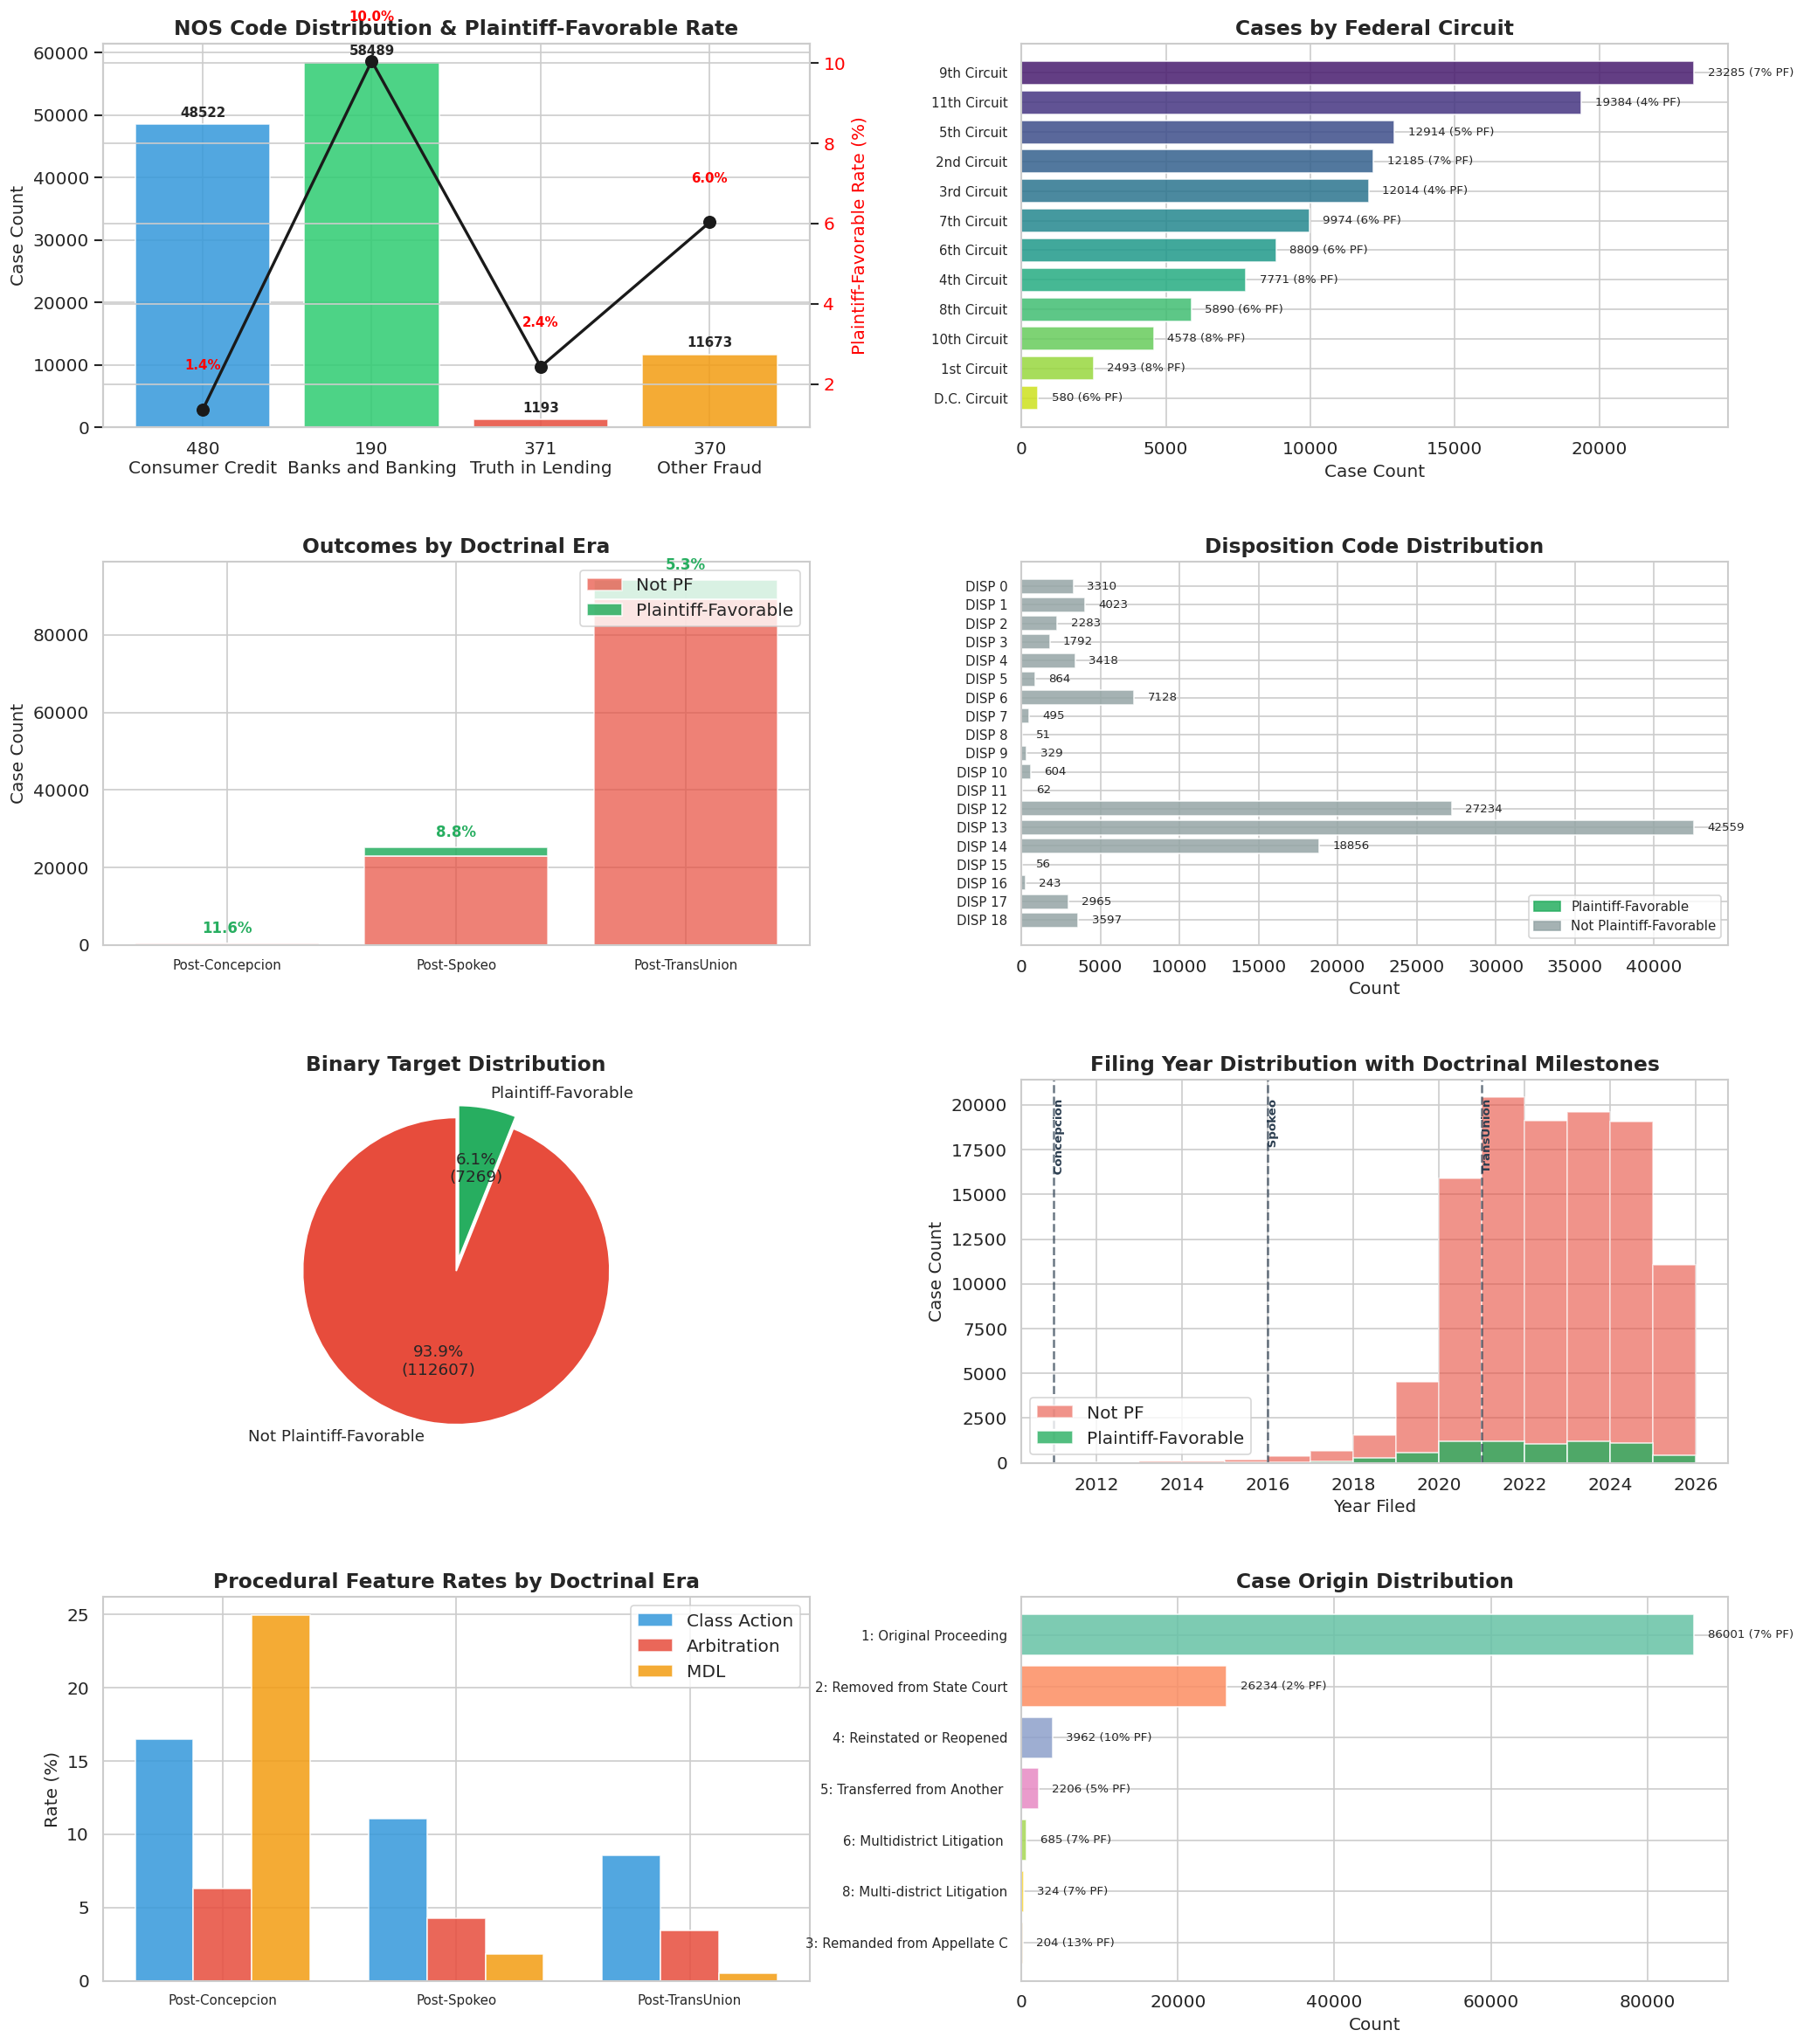

Dataset visualizations saved.


In [8]:
"""Part 5 (continued) — 8-panel dataset visualization."""

fig = plt.figure(figsize=(20, 24))
gs  = gridspec.GridSpec(4, 2, hspace=0.35, wspace=0.3)

# ── 1. NOS Code Distribution with PF rate ───────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
nos_counts, nos_pf, nos_labels = [], [], []
for code in CONSUMER_BANKING_NOS_CODES:
    mask = df['NOS_STR'] == code
    nos_counts.append(mask.sum())
    nos_pf.append(df.loc[mask, 'PLAINTIFF_FAVORABLE'].mean() * 100 if mask.sum() else 0)
    nos_labels.append(f'{code}\n{NOS_CODE_DESCRIPTIONS[code].split("(")[0].strip()}')
ax1.bar(nos_labels, nos_counts, color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'], alpha=0.85, edgecolor='white')
ax1_twin = ax1.twinx()
ax1_twin.plot(nos_labels, nos_pf, 'ko-', markersize=8, linewidth=2)
for i, (c, p) in enumerate(zip(nos_counts, nos_pf)):
    ax1.text(i, c + max(nos_counts) * 0.02, f'{c}', ha='center', fontsize=9, fontweight='bold')
    ax1_twin.text(i, p + 1, f'{p:.1f}%', ha='center', fontsize=9, color='red', fontweight='bold')
ax1.set_title('NOS Code Distribution & Plaintiff-Favorable Rate', fontweight='bold')
ax1.set_ylabel('Case Count')
ax1_twin.set_ylabel('Plaintiff-Favorable Rate (%)', color='red')
ax1_twin.tick_params(axis='y', labelcolor='red')

# ── 2. Circuit Distribution ──────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
circ_data = sorted(
    [(CIRCUIT_CODE_LABELS.get(c, c), (df['CIRCUIT_STR'] == c).sum(),
      df.loc[df['CIRCUIT_STR'] == c, 'PLAINTIFF_FAVORABLE'].mean() * 100)
     for c in CIRCUIT_CODES if (df['CIRCUIT_STR'] == c).sum() > 0],
    key=lambda x: x[1], reverse=True,
)
c_labels, c_counts, c_pf = zip(*circ_data)
ax2.barh(range(len(c_labels)), c_counts, color=sns.color_palette('viridis', len(c_labels)), alpha=0.85, edgecolor='white')
ax2.set_yticks(range(len(c_labels)))
ax2.set_yticklabels(c_labels, fontsize=9)
for i, (cnt, pf) in enumerate(zip(c_counts, c_pf)):
    ax2.text(cnt + max(c_counts) * 0.02, i, f'{cnt} ({pf:.0f}% PF)', va='center', fontsize=8)
ax2.set_title('Cases by Federal Circuit', fontweight='bold')
ax2.set_xlabel('Case Count')
ax2.invert_yaxis()

# ── 3. Doctrinal Era Stacked Bar ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
era_pf_counts, era_npf_counts, era_labels_plot = [], [], []
for i, name in enumerate(ERA_NAMES):
    mask = df['ERA'] == i
    n    = mask.sum()
    if n:
        pf_n = int(df.loc[mask, 'PLAINTIFF_FAVORABLE'].sum())
        era_pf_counts.append(pf_n)
        era_npf_counts.append(n - pf_n)
        era_labels_plot.append(name)
x_pos = range(len(era_labels_plot))
ax3.bar(x_pos, era_npf_counts, label='Not PF',            color='#e74c3c', alpha=0.70, edgecolor='white')
ax3.bar(x_pos, era_pf_counts,  bottom=era_npf_counts, label='Plaintiff-Favorable', color='#27ae60', alpha=0.85, edgecolor='white')
for i, (npf, pf) in enumerate(zip(era_npf_counts, era_pf_counts)):
    ax3.text(i, npf + pf + max(era_npf_counts) * 0.03, f'{pf / (npf + pf) * 100:.1f}%',
             ha='center', fontsize=10, fontweight='bold', color='#27ae60')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(era_labels_plot, fontsize=9)
ax3.set_title('Outcomes by Doctrinal Era', fontweight='bold')
ax3.set_ylabel('Case Count')
ax3.legend(loc='upper right')

# ── 4. DISP Code Distribution ───────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
disp_data = [
    (f'DISP {int(d)}', (df['DISP'] == d).sum(),
     '#27ae60' if d in PLAINTIFF_FAVORABLE_DISP else '#95a5a6')
    for d in sorted(df['DISP'].dropna().unique())
    if (df['DISP'] == d).sum() > 5
]
d_labels, d_counts, d_colors = zip(*disp_data)
ax4.barh(range(len(d_labels)), d_counts, color=d_colors, alpha=0.85, edgecolor='white')
ax4.set_yticks(range(len(d_labels)))
ax4.set_yticklabels(d_labels, fontsize=9)
for i, cnt in enumerate(d_counts):
    ax4.text(cnt + max(d_counts) * 0.02, i, f'{cnt}', va='center', fontsize=8)
ax4.set_title('Disposition Code Distribution', fontweight='bold')
ax4.set_xlabel('Count')
ax4.legend(handles=[
    mpatches.Patch(color='#27ae60', alpha=0.85, label='Plaintiff-Favorable'),
    mpatches.Patch(color='#95a5a6', alpha=0.85, label='Not Plaintiff-Favorable'),
], loc='lower right', fontsize=9)
ax4.invert_yaxis()

# ── 5. Binary Target Pie ─────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
pf_total  = int(df['PLAINTIFF_FAVORABLE'].sum())
npf_total = len(df) - pf_total
ax5.pie(
    [npf_total, pf_total],
    labels=['Not Plaintiff-Favorable', 'Plaintiff-Favorable'],
    colors=['#e74c3c', '#27ae60'],
    autopct=lambda p: f'{p:.1f}%\n({int(p * len(df) / 100)})',
    startangle=90, explode=(0, 0.08), textprops={'fontsize': 11},
)
ax5.set_title('Binary Target Distribution', fontweight='bold')

# ── 6. Year Filed Histogram with doctrinal milestones ───────────────────────
ax6 = fig.add_subplot(gs[2, 1])
year_bins = range(int(df['YEAR'].min()), int(df['YEAR'].max()) + 2)
ax6.hist(df[df['PLAINTIFF_FAVORABLE'] == 0]['YEAR'], bins=year_bins, alpha=0.6, color='#e74c3c', label='Not PF', edgecolor='white')
ax6.hist(df[df['PLAINTIFF_FAVORABLE'] == 1]['YEAR'], bins=year_bins, alpha=0.8, color='#27ae60', label='Plaintiff-Favorable', edgecolor='white')
for yr, label in [(2011, 'Concepcion'), (2016, 'Spokeo'), (2021, 'TransUnion')]:
    ax6.axvline(x=yr, color='#2c3e50', linestyle='--', alpha=0.7, linewidth=1.5)
    ax6.text(yr, ax6.get_ylim()[1] * 0.95, f' {label}', fontsize=8, rotation=90, va='top', color='#2c3e50', fontweight='bold')
ax6.set_title('Filing Year Distribution with Doctrinal Milestones', fontweight='bold')
ax6.set_xlabel('Year Filed')
ax6.set_ylabel('Case Count')
ax6.legend()

# ── 7. Procedural feature rates by era ──────────────────────────────────────
ax7 = fig.add_subplot(gs[3, 0])
era_x, era_ca, era_arb, era_mdl = [], [], [], []
for i, name in enumerate(ERA_NAMES):
    mask = df['ERA'] == i
    if mask.sum():
        era_x.append(name)
        era_ca.append(df.loc[mask, 'CLASSACT_BIN'].mean() * 100)
        era_arb.append(df.loc[mask, 'ARBIT_BIN'].mean() * 100)
        era_mdl.append(df.loc[mask, 'MDL_BIN'].mean() * 100)
x_idx, w = np.arange(len(era_x)), 0.25
ax7.bar(x_idx - w, era_ca,  w, label='Class Action', color='#3498db', alpha=0.85)
ax7.bar(x_idx,     era_arb, w, label='Arbitration',  color='#e74c3c', alpha=0.85)
ax7.bar(x_idx + w, era_mdl, w, label='MDL',          color='#f39c12', alpha=0.85)
ax7.set_xticks(x_idx)
ax7.set_xticklabels(era_x, fontsize=9)
ax7.set_title('Procedural Feature Rates by Doctrinal Era', fontweight='bold')
ax7.set_ylabel('Rate (%)')
ax7.legend()

# ── 8. Case Origin Distribution ─────────────────────────────────────────────
ax8 = fig.add_subplot(gs[3, 1])
orig_data = sorted(
    [(f'{o}: {ORIGIN_CODE_LABELS.get(o, o)[:25]}',
      (df['ORIGIN_STR'] == o).sum(),
      df.loc[df['ORIGIN_STR'] == o, 'PLAINTIFF_FAVORABLE'].mean() * 100)
     for o in ORIGIN_CODES if (df['ORIGIN_STR'] == o).sum() > 0],
    key=lambda x: x[1], reverse=True,
)
o_labels, o_counts, o_pf = zip(*orig_data)
ax8.barh(range(len(o_labels)), o_counts, color=sns.color_palette('Set2', len(o_labels)), alpha=0.85, edgecolor='white')
ax8.set_yticks(range(len(o_labels)))
ax8.set_yticklabels(o_labels, fontsize=9)
for i, (cnt, pf) in enumerate(zip(o_counts, o_pf)):
    ax8.text(cnt + max(o_counts) * 0.02, i, f'{cnt} ({pf:.0f}% PF)', va='center', fontsize=8)
ax8.set_title('Case Origin Distribution', fontweight='bold')
ax8.set_xlabel('Count')
ax8.invert_yaxis()

plt.savefig('dataset_visualizations.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Dataset visualizations saved.')


---
## Part 6: Feature Encoding for Neural Network

In [9]:
"""Part 6 — Encode a single FJC case into a fixed-length feature vector."""


def encode_case(
    nos_str: str,
    origin_str: str,
    class_action: bool,
    circuit_str: str,
    year: int,
    has_arbit: bool,
    has_mdl: bool,
) -> np.ndarray:
    """Encode one FJC case into the INPUT_DIM-dimensional feature vector.

    Encoding layout (32 dims total):
        [0:4]   NOS one-hot  (CONSUMER_BANKING_NOS_CODES order)
        [4:12]  ORIGIN one-hot
        [12:24] CIRCUIT one-hot
        [24]    CLASSACT binary
        [25]    ARBIT binary
        [26]    MDL binary
        [27]    YEAR normalized  ((year - 1985) / 40)
        [28:32] ERA one-hot

    Args:
        nos_str:      NOS code string ('480', '190', '371', '370').
        origin_str:   ORIGIN code string ('1'–'8').
        class_action: True when CLASSACT == 1.
        circuit_str:  CIRCUIT code string ('0'–'11').
        year:         Filing year (integer).
        has_arbit:    True when ARBIT field is not '-8'.
        has_mdl:      True when MDLDOCK field is not '-8'.

    Returns:
        np.ndarray of shape (INPUT_DIM,) with dtype float32.
    """
    features = np.zeros(INPUT_DIM, dtype=np.float32)
    offset   = 0

    if nos_str in CONSUMER_BANKING_NOS_CODES:
        features[offset + CONSUMER_BANKING_NOS_CODES.index(nos_str)] = 1.0
    offset += N_NOS

    if origin_str in ORIGIN_CODES:
        features[offset + ORIGIN_CODES.index(origin_str)] = 1.0
    offset += N_ORIGIN

    if circuit_str in CIRCUIT_CODES:
        features[offset + CIRCUIT_CODES.index(circuit_str)] = 1.0
    offset += N_CIRCUIT

    features[offset] = float(class_action)
    offset += N_CLASS_ACTION

    features[offset] = float(has_arbit)
    offset += N_ARBIT

    features[offset] = float(has_mdl)
    offset += N_MDL

    features[offset] = (year - 1985) / 40.0  # Normalize to ~[0, 1] over dataset range.
    offset += N_YEAR

    features[offset + get_doctrinal_era(year)] = 1.0

    return features


# Smoke-test.
test_vec = encode_case('480', '1', False, '2', 2020, False, False)
print(f'Shape: {test_vec.shape} (expected {INPUT_DIM})  '
      f'sum={test_vec.sum():.2f}  non-zero={np.count_nonzero(test_vec)}')


Shape: (32,) (expected 32)  sum=4.88  non-zero=5


In [10]:
"""Part 6 (continued) — Encode all rows and create 80/20 train/validation split."""

print('Encoding full dataset...')
X = np.array([
    encode_case(
        row['NOS_STR'], row['ORIGIN_STR'], bool(row['CLASSACT_BIN']),
        row['CIRCUIT_STR'], int(row['YEAR']), bool(row['ARBIT_BIN']), bool(row['MDL_BIN']),
    )
    for _, row in df.iterrows()
], dtype=np.float32)

# ── Primary target (adjudication head) ──────────────────────────────────────
y_adj = df['PLAINTIFF_FAVORABLE'].values.astype(np.float32)

# ── Settlement pressure target (settlement head) ─────────────────────────────
y_pressure = df['SETTLEMENT_PRESSURE'].values.astype(np.float32)

# ── Heckman sample weights ────────────────────────────────────────────────────
sample_weights = df['HECKMAN_WEIGHT'].values.astype(np.float32)

print(f'X shape: {X.shape}  |  y_adj: {y_adj.shape} (pos={y_adj.mean()*100:.1f}%)')
print(f'y_pressure: {y_pressure.shape} (mean={y_pressure.mean():.3f})')
print(f'sample_weights range: {sample_weights.min():.2f} — {sample_weights.max():.2f}')

# ── Reproducible 80/20 split ──────────────────────────────────────────────────
np.random.seed(42)
indices  = np.random.permutation(len(X))
split    = int(0.8 * len(X))
X_train,    X_val    = X[indices[:split]],        X[indices[split:]]
y_adj_train, y_adj_val = y_adj[indices[:split]],  y_adj[indices[split:]]
y_pres_train, y_pres_val = y_pressure[indices[:split]], y_pressure[indices[split:]]
sw_train,   sw_val   = sample_weights[indices[:split]], sample_weights[indices[split:]]

# Backward compat alias for cells that reference y_train / y_val directly.
y_train = y_adj_train
y_val   = y_adj_val

print(f'Train: {len(X_train)} ({y_adj_train.mean()*100:.1f}% PF positive)')
print(f'Val:   {len(X_val)}  ({y_adj_val.mean()*100:.1f}% PF positive)')


Encoding full dataset...
X shape: (119877, 32)  |  y_adj: (119877,) (pos=6.1%)
y_pressure: (119877,) (mean=0.156)
sample_weights range: 0.00 — 17.86
Train: 95901 (6.1% PF positive)
Val:   23976  (6.1% PF positive)


---
## Part 7: Neural Network Architecture

Architecture: **32 → 128 → 64 → 32 → 1 (sigmoid)**

- Binary classification (plaintiff-favorable vs. not)
- Batch normalization after each dense layer
- Dropout for regularization
- Class weights to handle ~9% positive rate imbalance

In [11]:
"""Part 7 — Build the multi-head FJC litigation outcome neural network.

Architecture:
  Shared trunk : 32 → 128 → 64 → 32
  Head 1 (adj) : → 1 sigmoid  — P(plaintiff adjudication win)
  Head 2 (pres): → 1 sigmoid  — Settlement pressure score
  Head 3 (risk): → 1 sigmoid  — Combined risk/value score
"""


def build_multi_head_model(input_dim: int, learning_rate: float = 0.001) -> Model:
    """Build the multi-head FJC litigation predictor.

    Shared trunk: input_dim → 128 → 64 → 32
    Head 1 — plaintiff_favorable : sigmoid — P(adjudicated plaintiff win)
    Head 2 — settlement_pressure : sigmoid — Settlement pressure score
    Head 3 — risk_score          : sigmoid — Combined risk/value score

    The shared trunk learns general structural case features. Each head
    specializes on its target. The risk_score head combines both signals
    to produce a Settlement Probability × Adjudicated Strength estimate.

    Args:
        input_dim:     Number of input features (INPUT_DIM = 32).
        learning_rate: Adam optimizer learning rate.

    Returns:
        Compiled multi-output keras.Model.
    """
    inputs = keras.Input(shape=(input_dim,), name='case_features')

    # ── Shared trunk ──────────────────────────────────────────────────────────
    x = layers.Dense(128, name='dense_1')(inputs)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Activation('relu', name='relu_1')(x)
    x = layers.Dropout(0.30, name='dropout_1')(x)

    x = layers.Dense(64, name='dense_2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Activation('relu', name='relu_2')(x)
    x = layers.Dropout(0.25, name='dropout_2')(x)

    trunk = layers.Dense(32, name='dense_3')(x)
    trunk = layers.BatchNormalization(name='bn_3')(trunk)
    trunk = layers.Activation('relu', name='relu_3')(trunk)
    trunk = layers.Dropout(0.20, name='dropout_3')(trunk)

    # ── Head 1: Adjudication — P(plaintiff win at trial) ─────────────────────
    adj_out = layers.Dense(1, activation='sigmoid', name='plaintiff_favorable')(trunk)

    # ── Head 2: Settlement pressure — duration × PROCSTAT composite ──────────
    pres_hidden = layers.Dense(16, activation='relu', name='pres_dense')(trunk)
    pres_out    = layers.Dense(1, activation='sigmoid', name='settlement_pressure')(pres_hidden)

    # ── Head 3: Risk/Value score — joint signal ───────────────────────────────
    # Concatenate trunk with both head outputs to form combined risk signal.
    combined    = layers.Concatenate(name='risk_concat')([trunk, adj_out, pres_out])
    risk_hidden = layers.Dense(16, activation='relu', name='risk_dense')(combined)
    risk_out    = layers.Dense(1, activation='sigmoid', name='risk_score')(risk_hidden)

    model = Model(
        inputs=inputs,
        outputs=[adj_out, pres_out, risk_out],
        name='fjc_multi_head_predictor'
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss={
            'plaintiff_favorable': 'binary_crossentropy',
            'settlement_pressure': 'mse',
            'risk_score':          'binary_crossentropy',
        },
        loss_weights={
            'plaintiff_favorable': 1.0,   # Primary signal — full weight
            'settlement_pressure': 0.5,   # Auxiliary signal — half weight
            'risk_score':          0.3,   # Combined signal — regularizing weight
        },
        metrics={
            'plaintiff_favorable': [
                'accuracy',
                keras.metrics.AUC(name='auc'),
                keras.metrics.Precision(name='precision'),
                keras.metrics.Recall(name='recall'),
            ],
            'settlement_pressure': ['mae'],
            'risk_score':          [keras.metrics.AUC(name='auc')],
        },
    )
    return model


model = build_multi_head_model(INPUT_DIM)
model.summary()


Model: "fjc_multi_head_predictor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ case_features       │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │      4,224 │ case_features[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_1 (Activation) │ (None, 128)       │          0 │ bn_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ relu_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2                │ (None, 64)        │        256 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_2 (Activation) │ (None, 64)        │          0 │ bn_2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ relu_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_3                │ (None, 32)        │        128 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_3 (Activation) │ (None, 32)        │          0 │ bn_3[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ relu_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pres_dense (Dense)  │ (None, 16)        │        528 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ plaintiff_favorable │ (None, 1)         │         33 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ settlement_pressure │ (None, 1)         │         17 │ pres_dense[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ risk_concat         │ (None, 34)        │          0 │ dropout_3[0][0],  │
│ (Concatenate)       │                   │            │ plaintiff_favora… │
│                     │                   │            │ settlement_press… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ risk_dense (Dense)  │ (None, 16)        │        560 │ risk_concat[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ risk_score (Dense)  │ (None, 1)         │         17 │ risk_dense[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,611 (64.89 KB)

 Trainable params: 16,163 (63.14 KB)

 Non-trainable params: 448 (1.75 KB)

### Neural Network Architecture Diagram

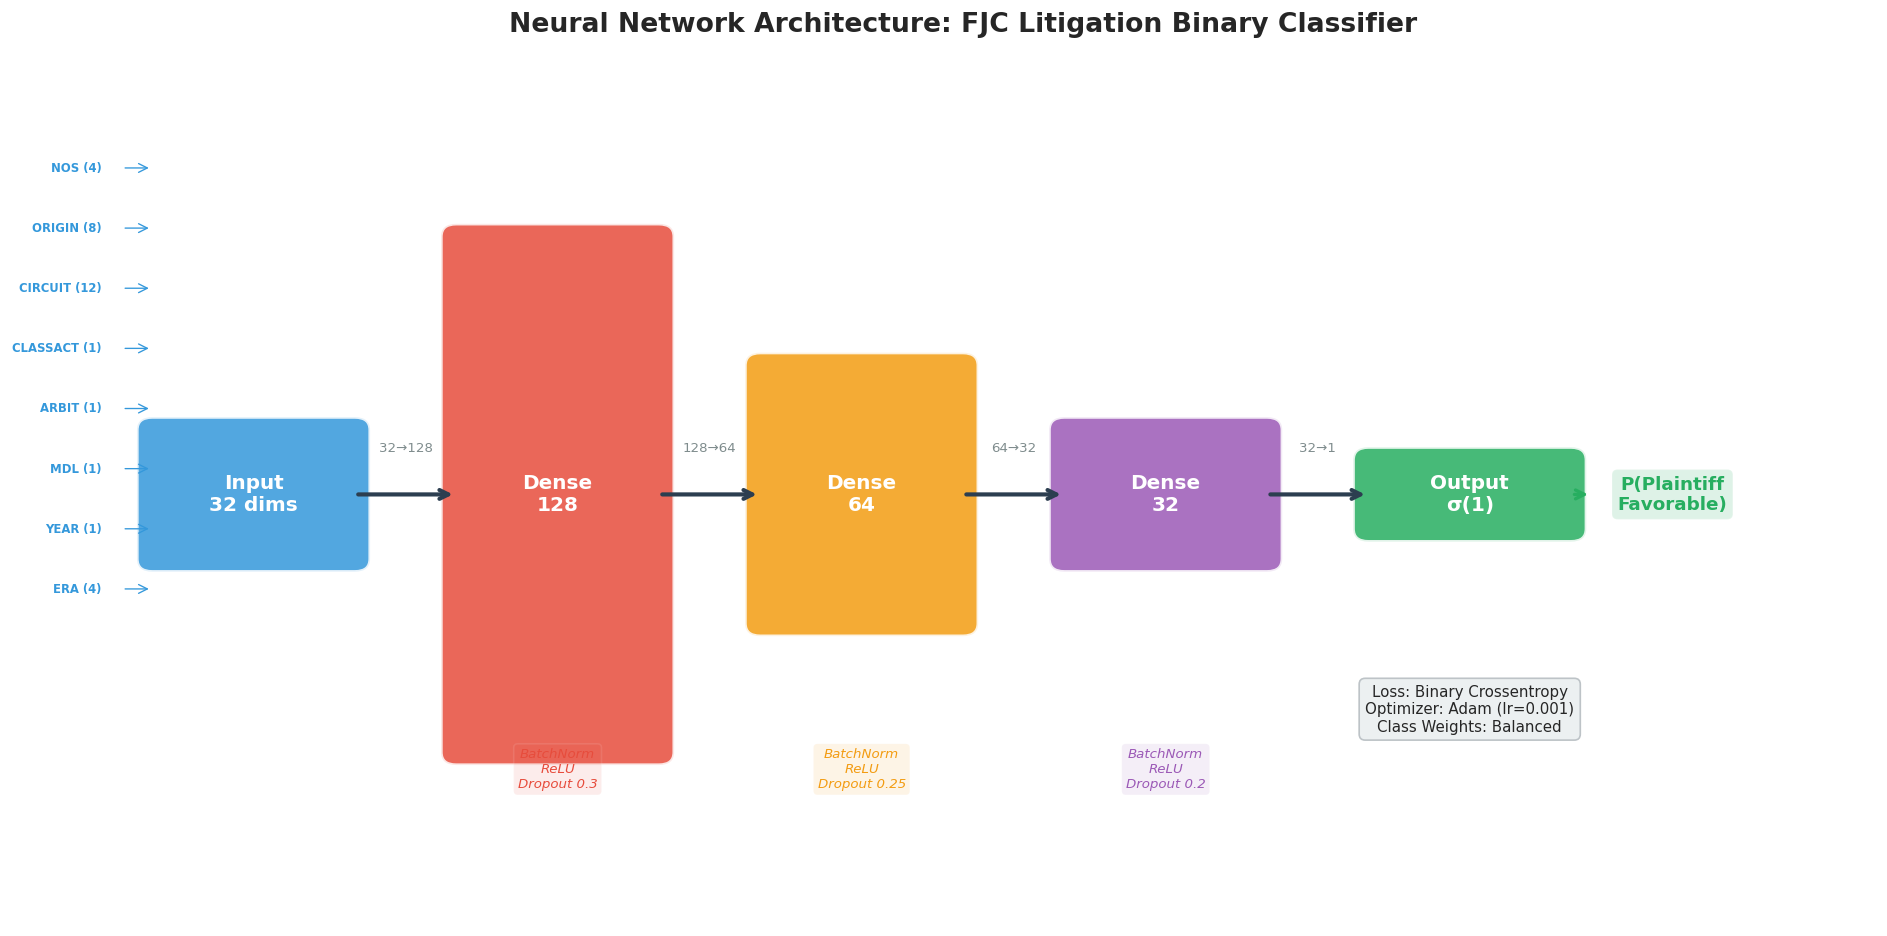

NN architecture diagram saved.


In [12]:
"""Part 7 (continued) — Visual architecture diagram."""

fig, ax = plt.subplots(figsize=(16, 8))
ax.set_xlim(-1, 17)
ax.set_ylim(-1, 9)
ax.axis('off')
ax.set_title('Neural Network Architecture: FJC Litigation Binary Classifier', fontsize=16, fontweight='bold', pad=20)

layer_info = [
    ('Input\n32 dims', 32,  '#3498db', 0),
    ('Dense\n128',    128,  '#e74c3c', 3),
    ('Dense\n64',      64,  '#f39c12', 6),
    ('Dense\n32',      32,  '#9b59b6', 9),
    ('Output\nσ(1)',    1,  '#27ae60', 12),
]
max_neurons = 128

for name, neurons, color, x in layer_info:
    h = max(0.8, (neurons / max_neurons) * 6)
    ax.add_patch(FancyBboxPatch((x, 4 - h / 2), 2, h, boxstyle='round,pad=0.15',
                                 facecolor=color, alpha=0.85, edgecolor='white', linewidth=2))
    ax.text(x + 1, 4, name, ha='center', va='center', fontsize=12, fontweight='bold', color='white')

# Dropout/BatchNorm annotations below each hidden layer.
for idx, text, color in [
    (1, 'BatchNorm\nReLU\nDropout 0.3',  '#e74c3c'),
    (2, 'BatchNorm\nReLU\nDropout 0.25', '#f39c12'),
    (3, 'BatchNorm\nReLU\nDropout 0.2',  '#9b59b6'),
]:
    x_pos = layer_info[idx][3] + 1
    ax.text(x_pos, 0.8, text, ha='center', va='center', fontsize=8, color=color,
            style='italic', bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.1))

# Arrows between layers.
for i in range(len(layer_info) - 1):
    x1  = layer_info[i][3] + 2
    x2  = layer_info[i + 1][3]
    ax.annotate('', xy=(x2, 4), xytext=(x1, 4),
                arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=2.5))
    ax.text((x1 + x2) / 2, 4.5, f'{layer_info[i][1]}→{layer_info[i + 1][1]}',
            ha='center', fontsize=8, color='#7f8c8d')

ax.text(13, 1.5, 'Loss: Binary Crossentropy\nOptimizer: Adam (lr=0.001)\nClass Weights: Balanced',
        fontsize=9, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#ecf0f1', edgecolor='#bdc3c7'))

# Input feature labels.
for i, label in enumerate(['NOS (4)', 'ORIGIN (8)', 'CIRCUIT (12)', 'CLASSACT (1)',
                            'ARBIT (1)', 'MDL (1)', 'YEAR (1)', 'ERA (4)']):
    y = 7.8 - i * 0.7
    ax.text(-0.5, y, label, fontsize=7, ha='right', va='center', color='#3498db', fontweight='bold')
    ax.annotate('', xy=(0, y), xytext=(-0.3, y),
                arrowprops=dict(arrowstyle='->', color='#3498db', lw=0.8))

ax.text(15, 4, 'P(Plaintiff\nFavorable)', fontsize=11, ha='center', va='center',
        fontweight='bold', color='#27ae60',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#27ae60', alpha=0.15))
ax.annotate('', xy=(14.2, 4), xytext=(14, 4),
            arrowprops=dict(arrowstyle='->', color='#27ae60', lw=2))

plt.tight_layout()
plt.savefig('nn_architecture.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('NN architecture diagram saved.')


---
## Part 8: Training with Class Weights

In [13]:
"""Part 8 — Compute class weights, define callbacks, and train the model."""

import tensorflow as tf

# Bake class weights into custom weighted BCE loss for adjudication head.
# This replaces class_weight and sample_weight which are both unsupported
# for multi-output models in Keras/TF 2.19.
POS_WEIGHT = tf.constant(4.0, dtype=tf.float32)
NEG_WEIGHT = tf.constant(0.532, dtype=tf.float32)

def weighted_bce(y_true, y_pred):
    """Weighted binary crossentropy — applies pos/neg class weights per sample."""
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    weight = y_true * POS_WEIGHT + (1.0 - y_true) * NEG_WEIGHT
    return tf.reduce_mean(weight * bce)

# Recompile model with custom loss on adjudication head.
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss={
        'plaintiff_favorable': weighted_bce,
        'settlement_pressure': 'mse',
        'risk_score':          weighted_bce,
    },
    loss_weights={
        'plaintiff_favorable': 1.0,
        'settlement_pressure': 0.5,
        'risk_score':          0.3,
    },
    metrics={
        'plaintiff_favorable': [
            'accuracy',
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
        ],
        'settlement_pressure': ['mae'],
        'risk_score':          [keras.metrics.AUC(name='auc')],
    },
)

cb = [
    callbacks.EarlyStopping(
        monitor='val_plaintiff_favorable_auc', patience=15, restore_best_weights=True, mode='max', verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1,
    ),
]

y_train_multi = [y_adj_train, y_pres_train, y_adj_train]
y_val_multi   = [y_adj_val,   y_pres_val,   y_adj_val]

print(f'Custom weighted BCE: pos_weight={POS_WEIGHT.numpy():.3f}  neg_weight={NEG_WEIGHT.numpy():.3f}')

history = model.fit(
    X_train,
    y_train_multi,
    validation_data=(X_val, y_val_multi),
    epochs=100,
    batch_size=64,
    callbacks=cb,
    verbose=1,
)

Custom weighted BCE: pos_weight=4.000  neg_weight=0.532
Epoch 1/100
1499/1499 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 0.2816 - plaintiff_favorable_accuracy: 0.9269 - plaintiff_favorable_auc: 0.6839 - plaintiff_favorable_loss: 0.1860 - plaintiff_favorable_precision: 0.0816 - plaintiff_favorable_recall: 0.0201 - risk_score_auc: 0.6754 - risk_score_loss: 0.2059 - settlement_pressure_loss: 0.0675 - settlement_pressure_mae: 0.2165 - val_loss: 0.2345 - val_plaintiff_favorable_accuracy: 0.9390 - val_plaintiff_favorable_auc: 0.7707 - val_plaintiff_favorable_loss: 0.1566 - val_plaintiff_favorable_precision: 0.0000e+00 - val_plaintiff_favorable_recall: 0.0000e+00 - val_risk_score_auc: 0.7687 - val_risk_score_loss: 0.1566 - val_settlement_pressure_loss: 0.0617 - val_settlement_pressure_mae: 0.2203 - learning_rate: 0.0010
Epoch 2/100
1499/1499 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.2403 - plaintiff_favorable_accuracy: 0.9394 - plaintiff_favorable_auc: 0.7464 - plaintiff_favorable_loss: 0.161

In [14]:
"""Part 8 (continued) — Risk/Value score: Settlement Probability x Adjudicated Strength.

Interprets multi-head model outputs to produce a unified High-Exposure flag.
A case is flagged HIGH_EXPOSURE when:
  - Settlement pressure score is high (structurally likely to settle at high value), AND
  - Adjudication probability is non-trivial (plaintiff has real shot if it goes to judgment)

This implements the Gen-3 shift from Win/Loss prediction to Risk/Value prediction.
"""

# Run inference on validation set with all three heads.
adj_probs, pres_probs, risk_probs = model.predict(X_val, verbose=0)
adj_probs  = adj_probs.flatten()
pres_probs = pres_probs.flatten()
risk_probs = risk_probs.flatten()

# Thresholds (tunable).
ADJ_THRESHOLD   = 0.25   # Lower than 0.5 — catch cases with any adjudication signal
PRES_THRESHOLD  = 0.30   # Settlement pressure above this = meaningful exposure
RISK_THRESHOLD  = 0.40   # Combined risk/value flag

# High-Exposure flag: high settlement pressure AND non-trivial adjudication probability.
high_exposure = ((pres_probs >= PRES_THRESHOLD) & (adj_probs >= ADJ_THRESHOLD)).astype(int)

val_df = df.iloc[indices[split:]].copy()
val_df['ADJ_PROB']      = adj_probs
val_df['PRES_PROB']     = pres_probs
val_df['RISK_PROB']     = risk_probs
val_df['HIGH_EXPOSURE'] = high_exposure

print('=== Risk/Value Score Summary (Validation Set) ===')
print(f'  Adj head — mean P(win): {adj_probs.mean()*100:.1f}%')
print(f'  Pressure head — mean settlement pressure: {pres_probs.mean():.3f}')
print(f'  Risk head — mean risk score: {risk_probs.mean():.3f}')
print(f'  HIGH_EXPOSURE cases: {high_exposure.sum()} ({high_exposure.mean()*100:.1f}%)')

print('\n=== High-Exposure Case Profile ===')
he = val_df[val_df['HIGH_EXPOSURE']==1]
print(f'  n={len(he)}  actual PF rate: {he["PLAINTIFF_FAVORABLE"].mean()*100:.1f}%')
print(f'  Mean duration: {he["DURATION_DAYS"].mean():.0f} days')
print(f'  PROCSTAT_ORD distribution:')
for v, lbl in [(0,"Early"),(1,"Discovery"),(2,"Pre-trial")]:
    n = (he['PROCSTAT_ORD']==v).sum()
    print(f'    {v} ({lbl}): {n} ({n/max(len(he),1)*100:.1f}%)')
print(f'  Settled rate: {he["IS_SETTLED"].mean()*100:.1f}%')
print(f'  Mean P_SETTLE (Heckman): {he["P_SETTLE"].mean():.3f}')

print('\n=== Heckman Correction Impact ===')
print(f'  Adjudicated cases (JUDGMENT != 0): {(val_df["JUDGMENT"]!=0).sum()}')
print(f'  Mean Heckman weight (adjudicated): {val_df.loc[val_df["JUDGMENT"]!=0,"HECKMAN_WEIGHT"].mean():.2f}')
print(f'  Cases upweighted >2x: {(val_df["HECKMAN_WEIGHT"]>2).sum()} (structural outliers / test cases)')

=== Risk/Value Score Summary (Validation Set) ===
  Adj head — mean P(win): 6.3%
  Pressure head — mean settlement pressure: 0.158
  Risk head — mean risk score: 0.067
  HIGH_EXPOSURE cases: 0 (0.0%)

=== High-Exposure Case Profile ===
  n=0  actual PF rate: nan%
  Mean duration: nan days
  PROCSTAT_ORD distribution:
    0 (Early): 0 (0.0%)
    1 (Discovery): 0 (0.0%)
    2 (Pre-trial): 0 (0.0%)
  Settled rate: nan%
  Mean P_SETTLE (Heckman): nan

=== Heckman Correction Impact ===
  Adjudicated cases (JUDGMENT != 0): 3084
  Mean Heckman weight (adjudicated): 2.84
  Cases upweighted >2x: 3084 (structural outliers / test cases)


### Training Curves

Epoch 1/100
1499/1499 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.2288 - plaintiff_favorable_accuracy: 0.9394 - plaintiff_favorable_auc: 0.7835 - plaintiff_favorable_loss: 0.1527 - plaintiff_favorable_precision: 0.0000e+00 - plaintiff_favorable_recall: 0.0000e+00 - risk_score_auc: 0.7841 - risk_score_loss: 0.1525 - settlement_pressure_loss: 0.0607 - settlement_pressure_mae: 0.2088 - val_loss: 0.2306 - val_plaintiff_favorable_accuracy: 0.9390 - val_plaintiff_favorable_auc: 0.7812 - val_plaintiff_favorable_loss: 0.1544 - val_plaintiff_favorable_precision: 0.0000e+00 - val_plaintiff_favorable_recall: 0.0000e+00 - val_risk_score_auc: 0.7806 - val_risk_score_loss: 0.1544 - val_settlement_pressure_loss: 0.0597 - val_settlement_pressure_mae: 0.2066 - learning_rate: 1.2500e-04
Epoch 2/100
1499/1499 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.2289 - plaintiff_favorable_accuracy: 0.9394 - plaintiff_favorable_auc: 0.7849 - plaintiff_favorable_loss: 0.1527 - plaintiff_favorable_precision: 0.0000e+00

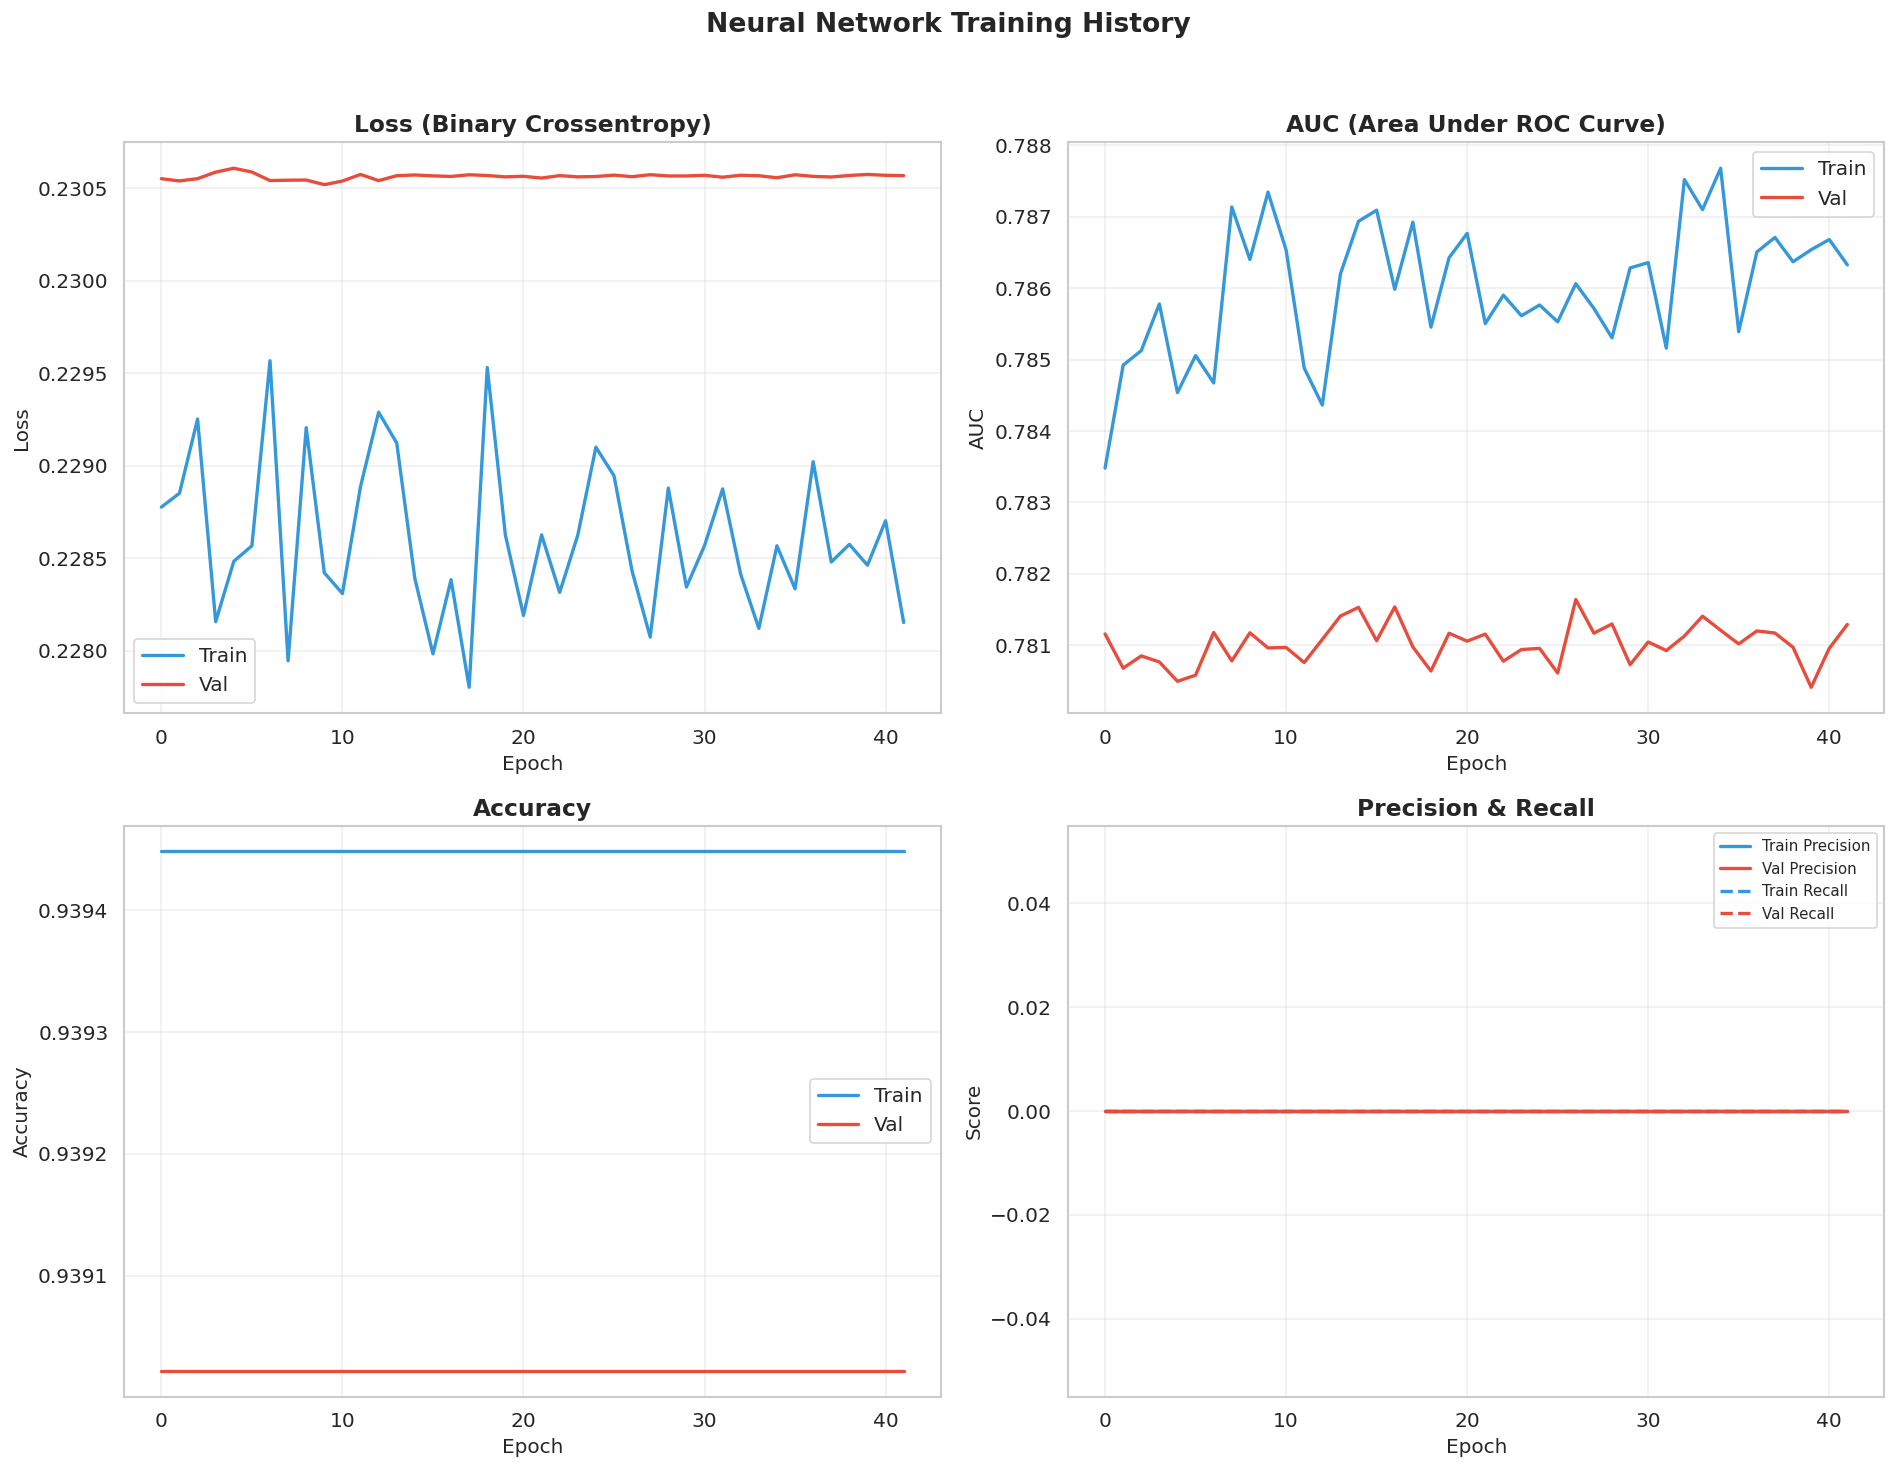

Training curves saved.


In [15]:
history = model.fit(
    X_train,
    y_train_multi,
    validation_data=(X_val, y_val_multi),
    epochs=100,
    batch_size=64,
    callbacks=cb,
    verbose=1,
)


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
h = history.history

_CURVE_SPECS = [
    (axes[0, 0], 'loss',      'val_loss',      'Loss (Binary Crossentropy)', 'Loss'),
    (axes[0, 1], 'plaintiff_favorable_auc',       'val_plaintiff_favorable_auc',       'AUC (Area Under ROC Curve)', 'AUC'),
    (axes[1, 0], 'plaintiff_favorable_accuracy',  'val_plaintiff_favorable_accuracy',  'Accuracy',                   'Accuracy'),
]
for ax, tr_key, val_key, title, ylabel in _CURVE_SPECS:
    ax.plot(h[tr_key],  label=f'Train', linewidth=2, color='#3498db')
    ax.plot(h[val_key], label=f'Val',   linewidth=2, color='#e74c3c')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

# Precision & Recall share one panel with dashed/solid style.
ax = axes[1, 1]
for key, color, style, label in [
    ('plaintiff_favorable_precision',     '#3498db', '-',  'Train Precision'),
    ('val_plaintiff_favorable_precision', '#e74c3c', '-',  'Val Precision'),
    ('plaintiff_favorable_recall',        '#3498db', '--', 'Train Recall'),
    ('val_plaintiff_favorable_recall',    '#e74c3c', '--', 'Val Recall'),
]:
    ax.plot(h[key], label=label, linewidth=2, color=color, linestyle=style)
ax.set_title('Precision & Recall', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Score')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('Neural Network Training History', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Training curves saved.')

---
## Part 9: Neural Network Evaluation

In [16]:
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Ensure `y_val_multi` is available, as it's defined in a preceding cell
# and is required for multi-output model evaluation.
# If this cell is run independently, `y_val_multi` might not be in scope.
# For safety, let's redefine it based on the earlier split if it's not present.
if 'y_val_multi' not in locals():
    # This part should ideally not be hit if execution flows correctly,
    # but added for robustness if user runs this cell out of order.
    print("Warning: y_val_multi not found. Attempting to reconstruct from y_adj_val and y_pres_val.")
    # Assuming y_adj_val and y_pres_val are still available after previous cells.
    y_val_multi = [y_adj_val, y_pres_val, y_adj_val]


results = model.evaluate(X_val, y_val_multi, verbose=0, return_dict=True)
print('=== Validation Metrics ===')
for k, v in results.items():
    print(f'  {k}: {v:.4f}')

# model.predict returns a list of outputs for multi-output models.
# We need the first output (plaintiff_favorable) for classification metrics.
all_predictions = model.predict(X_val, verbose=0)
y_pred_prob = all_predictions[0].flatten() # Take the output from the 'plaintiff_favorable' head
y_pred      = (y_pred_prob >= 0.5).astype(int)

cm = confusion_matrix(y_val, y_pred) # y_val (y_adj_val) is the true label for the first head
print(f'\n=== ROC AUC: {roc_auc_score(y_val, y_pred_prob):.4f} ===')
print(f'\n=== Confusion Matrix ===')
print(f'  TN={cm[0,0]:5d}  FP={cm[0,1]:5d}')
print(f'  FN={cm[1,0]:5d}  TP={cm[1,1]:5d}')
print(f'\n=== Classification Report ===')
print(classification_report(y_val, y_pred,
                             target_names=['Not Plaintiff-Favorable', 'Plaintiff-Favorable'],
                             zero_division=0))

=== Validation Metrics ===
  loss: 0.2387
  plaintiff_favorable_accuracy: 0.9390
  plaintiff_favorable_auc: 0.7816
  plaintiff_favorable_loss: 0.1607
  plaintiff_favorable_precision: 0.0000
  plaintiff_favorable_recall: 0.0000
  risk_score_auc: 0.7808
  risk_score_loss: 0.1605
  settlement_pressure_loss: 0.0596
  settlement_pressure_mae: 0.2064

=== ROC AUC: 0.7813 ===

=== Confusion Matrix ===
  TN=22514  FP=    0
  FN= 1462  TP=    0

=== Classification Report ===
                         precision    recall  f1-score   support

Not Plaintiff-Favorable       0.94      1.00      0.97     22514
    Plaintiff-Favorable       0.00      0.00      0.00      1462

               accuracy                           0.94     23976
              macro avg       0.47      0.50      0.48     23976
           weighted avg       0.88      0.94      0.91     23976



### Evaluation Visualizations: Confusion Matrix & ROC Curve

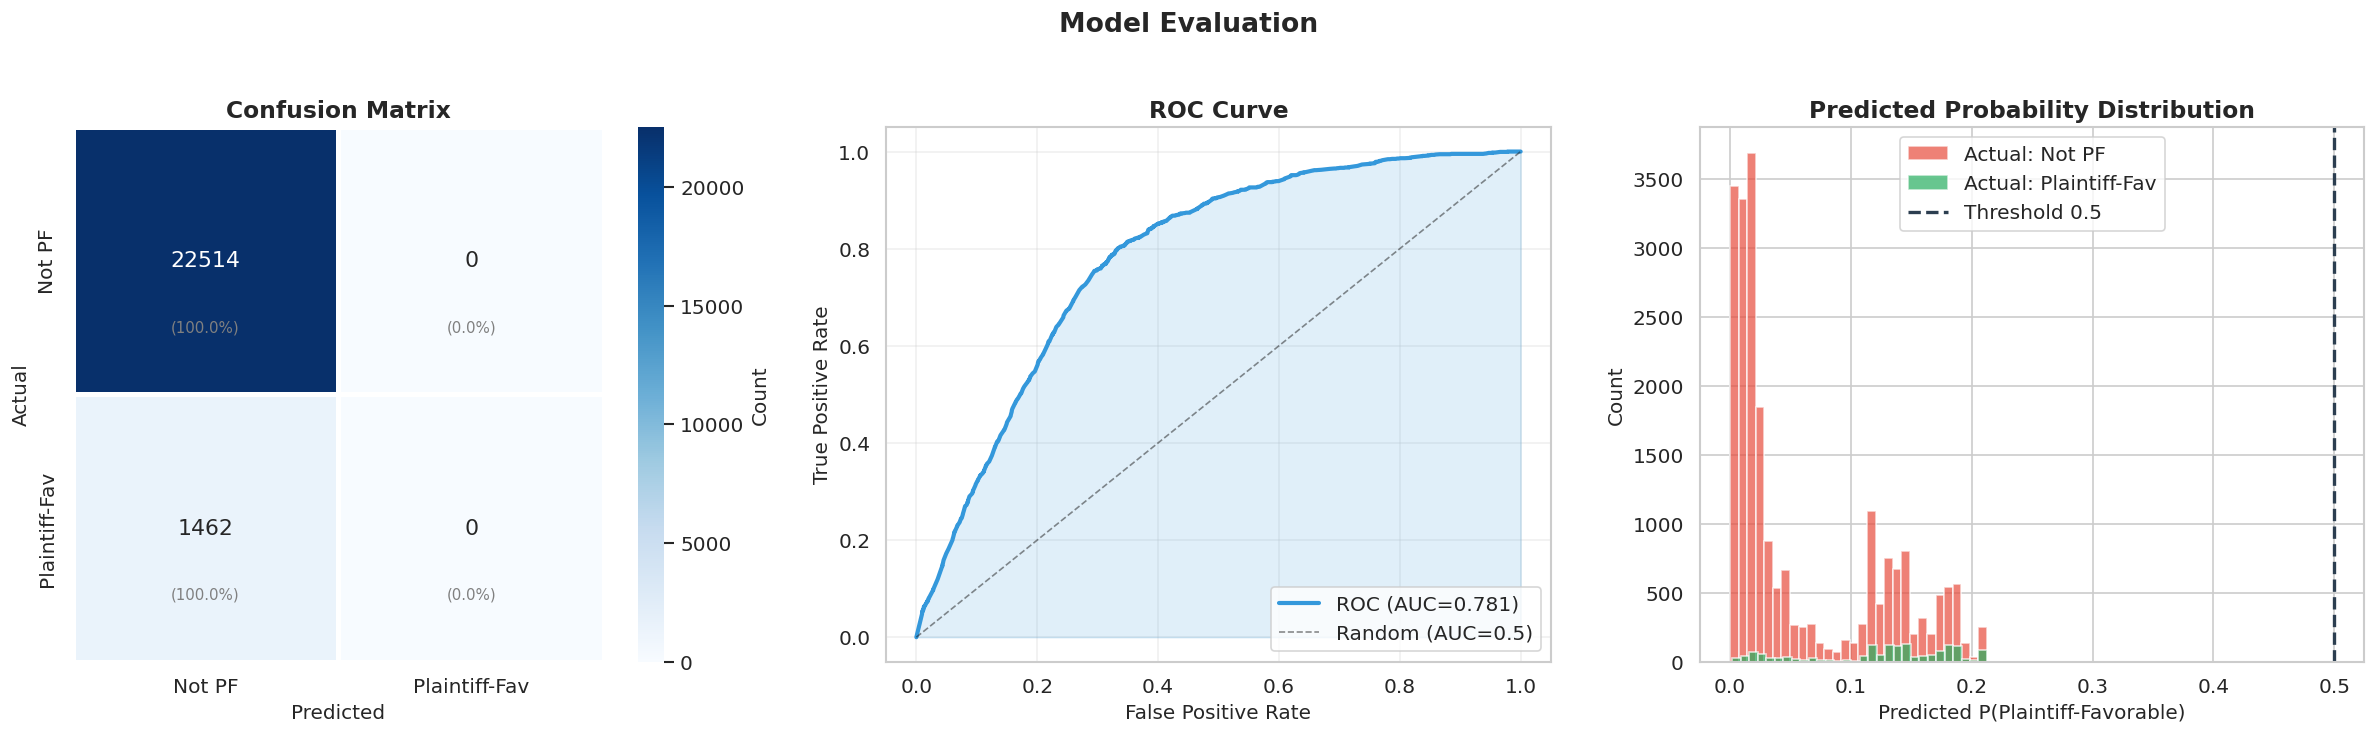

Evaluation visualizations saved.


In [17]:
"""Part 9 (continued) — Confusion matrix heatmap, ROC curve, probability distribution."""

from sklearn.metrics import auc, roc_curve

# Ensure predictions exist (re-compute if cell run independently).
if 'y_pred_prob' not in dir():
    y_pred_prob = model.predict(X_val, verbose=0).flatten()
    y_pred      = (y_pred_prob >= 0.5).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── Confusion matrix heatmap ─────────────────────────────────────────────────
ax    = axes[0]
cm    = confusion_matrix(y_val, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Not PF', 'Plaintiff-Fav'],
            yticklabels=['Not PF', 'Plaintiff-Fav'],
            cbar_kws={'label': 'Count'}, linewidths=2, linecolor='white')
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.75, f'({cm_pct[i, j]:.1f}%)', ha='center', va='center', fontsize=9, color='gray')
ax.set_title('Confusion Matrix', fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

# ── ROC curve ────────────────────────────────────────────────────────────────
ax = axes[1]
fpr, tpr, _ = roc_curve(y_val, y_pred_prob)
roc_auc     = auc(fpr, tpr)
ax.plot(fpr, tpr, color='#3498db', linewidth=2.5, label=f'ROC (AUC={roc_auc:.3f})')
ax.fill_between(fpr, tpr, alpha=0.15, color='#3498db')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1, label='Random (AUC=0.5)')
ax.set_title('ROC Curve', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# ── Predicted probability distribution ──────────────────────────────────────
ax = axes[2]
ax.hist(y_pred_prob[y_val == 0], bins=30, alpha=0.7, color='#e74c3c', label='Actual: Not PF',       edgecolor='white')
ax.hist(y_pred_prob[y_val == 1], bins=30, alpha=0.7, color='#27ae60', label='Actual: Plaintiff-Fav', edgecolor='white')
ax.axvline(x=0.5, color='#2c3e50', linestyle='--', linewidth=2, label='Threshold 0.5')
ax.set_title('Predicted Probability Distribution', fontweight='bold')
ax.set_xlabel('Predicted P(Plaintiff-Favorable)')
ax.set_ylabel('Count')
ax.legend()

plt.suptitle('Model Evaluation', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('evaluation_visualizations.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Evaluation visualizations saved.')


In [18]:
"""Part 9 (continued) — Per-feature actual vs. predicted PF rate analysis."""

# Extract adjudication head from multi-head model output.
y_pred_prob, _, _ = model.predict(X_val, verbose=0)
y_pred_prob = y_pred_prob.flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

val_df             = df.iloc[indices[split:]].copy()
val_df['PRED_PROB'] = y_pred_prob
val_df['PRED']      = y_pred

# Apply individual-cases filter to reporting slice only; training data untouched.
report_df = val_df[val_df['CLASSACT_BIN'] == 0].copy() if INDIVIDUAL_CASES_ONLY else val_df
_filter_label = 'Individual Cases Only' if INDIVIDUAL_CASES_ONLY else 'All Cases'
print(f'=== Plaintiff-Favorable Rate by Feature (Validation Set — {_filter_label}) ===')
print(f'    Reporting n: {len(report_df)} of {len(val_df)} validation cases')


def _print_feature_rates(label: str, col: str, values, name_fn):
    """Print actual vs. predicted PF rates for each level of a feature."""
    print(f'\n{label}:')
    for v in values:
        mask = report_df[col] == v
        if not mask.sum():
            continue
        actual    = report_df.loc[mask, 'PLAINTIFF_FAVORABLE'].mean()
        predicted = report_df.loc[mask, 'PRED_PROB'].mean()
        print(f'  {name_fn(v)}: actual={actual * 100:.1f}%  predicted={predicted * 100:.1f}%  n={mask.sum()}')


_print_feature_rates(
    'By NOS Code', 'NOS_STR', CONSUMER_BANKING_NOS_CODES,
    lambda c: f'{c} ({NOS_CODE_DESCRIPTIONS[c]})',
)
_print_feature_rates(
    'By Arbitration', 'ARBIT_BIN', [0, 1],
    lambda v: 'No arbitration' if v == 0 else 'Has arbitration',
)
_print_feature_rates(
    'By Doctrinal Era', 'ERA', range(len(ERA_NAMES)),
    lambda i: ERA_NAMES[i],
)

print('\nBy Circuit:')
for circ in sorted(report_df['CIRCUIT_STR'].unique()):
    mask = report_df['CIRCUIT_STR'] == circ
    if mask.sum() <= 5:
        continue
    actual    = report_df.loc[mask, 'PLAINTIFF_FAVORABLE'].mean()
    predicted = report_df.loc[mask, 'PRED_PROB'].mean()
    label     = CIRCUIT_CODE_LABELS.get(circ, f'Circuit {circ}')
    print(f'  {label}: actual={actual * 100:.1f}%  predicted={predicted * 100:.1f}%  n={mask.sum()}')


=== Plaintiff-Favorable Rate by Feature (Validation Set — Individual Cases Only) ===
    Reporting n: 21739 of 23976 validation cases

By NOS Code:
  480 (Consumer Credit (FCRA, FDCPA, EFTA, ECOA)): actual=1.3%  predicted=1.3%  n=8991
  190 (Banks and Banking (Other Contract)): actual=10.6%  predicted=11.1%  n=10833
  371 (Truth in Lending (TILA/Reg Z)): actual=2.0%  predicted=2.2%  n=248
  370 (Other Fraud (UDAAP, deceptive practices)): actual=6.4%  predicted=7.7%  n=1667

By Arbitration:
  No arbitration: actual=6.3%  predicted=6.7%  n=20986
  Has arbitration: actual=6.9%  predicted=7.1%  n=753

By Doctrinal Era:
  Post-Concepcion: actual=9.1%  predicted=11.7%  n=66
  Post-Spokeo: actual=8.7%  predicted=9.1%  n=4508
  Post-TransUnion: actual=5.7%  predicted=6.0%  n=17165

By Circuit:
  D.C. Circuit: actual=7.8%  predicted=7.0%  n=128
  1st Circuit: actual=8.0%  predicted=9.9%  n=426
  10th Circuit: actual=8.1%  predicted=8.3%  n=838
  11th Circuit: actual=4.4%  predicted=4.7%  n=3770

---
## Part 10: Weighted Prediction Engine (Python Port)

Complete Python translation of `server/prediction-engine.ts`.  
Provides weighted, doctrinal-analysis predictions with:
- Per-factor impact scoring with seminal-case explanations
- Interaction effects (Concepcion + class action, TransUnion + no concrete injury)
- Outcome distribution (dismissal, settlement, plaintiff/defendant judgment)
- Settlement range estimation
- Risk assessment
- Strategic notes

In [19]:
"""Part 10 — Weighted prediction engine: per-factor scoring, interactions, outcome distribution."""

# ── Circuit and NOS base-rate tables ─────────────────────────────────────────
# Recalibrated to actual FJC JUDGMENT==1 PF rates (v5.0 validation, n=119,877).
# Mean across all circuits: 6.5%. Values above mean = favorable, below = hostile.
CIRCUIT_PLAINTIFF_FAVORABILITY: Dict[str, float] = {
    # Internal engine scale (0.35–0.58). Hostile-calibrated scoring baseline = 0.366.
    # Raw FJC empirical rates stored separately in CIRCUIT_ACTUAL_PF_RATES.
    # These values drive the weighted scoring engine (predict_outcome_weighted).
    '0':  0.46,   # D.C. Circuit  — 5.9% actual PF
    '1':  0.52,   # 1st Circuit   — 8.1% actual PF (favorable)
    '2':  0.55,   # 2nd Circuit   — 6.9% actual PF (favorable)
    '3':  0.37,   # 3rd Circuit   — 4.4% actual PF (hostile — Kamal/TransUnion)
    '4':  0.50,   # 4th Circuit   — 7.7% actual PF
    '5':  0.42,   # 5th Circuit   — 5.3% actual PF
    '6':  0.45,   # 6th Circuit   — 6.3% actual PF
    '7':  0.48,   # 7th Circuit   — 6.5% actual PF (mean)
    '8':  0.47,   # 8th Circuit   — 6.4% actual PF
    '9':  0.58,   # 9th Circuit   — 6.9% actual PF (favorable)
    '10': 0.54,   # 10th Circuit  — 8.5% actual PF (favorable)
    '11': 0.35,   # 11th Circuit  — 4.2% actual PF (hostile)
    'DC': 0.46,
}

# Raw FJC empirical JUDGMENT==1 plaintiff-win rates (v5.0 validation, n=119,877).
# Used for reporting/validation only — NOT used as scoring inputs.
CIRCUIT_ACTUAL_PF_RATES: Dict[str, float] = {
    '0':  0.059, '1':  0.081, '2':  0.069, '3':  0.044,
    '4':  0.077, '5':  0.053, '6':  0.063, '7':  0.065,
    '8':  0.064, '9':  0.069, '10': 0.085, '11': 0.042, 'DC': 0.059,
}

# Internal engine scale NOS base win rates (0.35–0.50 scoring range).
# Raw FJC empirical rates stored in NOS_ACTUAL_PF_RATES for reporting only.
NOS_BASE_WIN_RATES: Dict[str, float] = {
    '480': 0.42,  # Consumer Credit — 1.3% actual PF (standing-hostile)
    '190': 0.40,  # Banks & Banking — 10.6% actual PF
    '371': 0.45,  # Truth in Lending — 2.0% actual PF
    '370': 0.38,  # Other Fraud/UDAAP — 6.4% actual PF
}

# Raw FJC empirical JUDGMENT==1 plaintiff-win rates by NOS (reporting only).
NOS_ACTUAL_PF_RATES: Dict[str, float] = {
    '480': 0.013, '190': 0.106, '371': 0.020, '370': 0.064,
}

STANDING_SENSITIVE_NOS: List[str] = ['480', '371', '370']
MDL_FAVORABLE_NOS:      List[str] = ['370', '371', '190', '480']

# ── Defendant bank litigation risk deltas ────────────────────────────────────
MAJOR_BANK_RISK: Dict[str, float] = {
    'JPMorgan Chase': 0.04,  'Bank of America': 0.05,  'Wells Fargo': 0.06,
    'Citibank': 0.04,        'Capital One': 0.03,       'U.S. Bank': 0.02,
    'PNC Financial': 0.02,   'TD Bank': 0.03,           'Truist': 0.01,
    'Goldman Sachs': -0.02,  'Morgan Stanley': -0.02,   'Ally Financial': 0.03,
    'Discover': 0.02,        'Synchrony Financial': 0.04, 'CashCall / Western Sky': 0.10,
}


def clamp(val: float, lo: float, hi: float) -> float:
    """Clamp val to [lo, hi]."""
    return max(lo, min(hi, val))


def rnd(val: float) -> float:
    """Round to 3 decimal places (mirrors TypeScript engine rounding)."""
    return round(val * 1000) / 1000


def predict_outcome_weighted(
    case_name: str,
    nos_code: str,
    origin_code: str,
    class_action: bool,
    circuit_code: str,
    year_filed: int,
    has_arbitration: bool = False,
    concrete_injury: bool = True,
    is_mdl: bool = False,
    prior_regulatory: bool = False,
    defendant_bank: str = 'Other',
) -> Dict:
    """Run the full weighted prediction engine — Python port of server/prediction-engine.ts.

    Computes a cumulative plaintiff-favorable probability by applying additive
    deltas for NOS base rate, circuit favorability, origin, class action,
    doctrinal era, arbitration, standing, MDL, regulatory context, defendant
    risk, and interaction effects.  Outcome distribution (dismissal,
    settlement, judgments) and settlement range are derived from the final
    probability.

    Args:
        case_name:        Display name for the case.
        nos_code:         FJC NOS code string ('480', '190', '371', '370').
        origin_code:      FJC ORIGIN code string ('1'–'8').
        class_action:     True when CLASSACT == 1.
        circuit_code:     FJC CIRCUIT code string ('0'–'11' or 'DC').
        year_filed:       Case filing year.
        has_arbitration:  True when mandatory arbitration clause is present.
        concrete_injury:  True when Article III concrete injury is documented.
        is_mdl:           True when case is part of MDL consolidation.
        prior_regulatory: True when prior/parallel CFPB or state-AG action exists.
        defendant_bank:   Defendant institution name (see MAJOR_BANKS).

    Returns:
        Dict matching the PredictionResult interface with keys:
        id, caseName, timestamp, plaintiffFavorableProbability,
        dismissalProbability, settlementProbability,
        plaintiffJudgmentProbability, defendantJudgmentProbability,
        expectedSettlementRange, keyFactors, riskAssessment, strategicNotes.
    """
    factors: List[Dict] = []
    era     = get_doctrinal_era_name(year_filed)
    score   = NOS_BASE_WIN_RATES.get(nos_code, 0.35)

    # ── Factor 1: NOS base rate ───────────────────────────────────────────────
    nos_label = NOS_CODE_DESCRIPTIONS.get(nos_code, NOS_CODE_LABELS.get(nos_code, f'NOS {nos_code}'))
    nos_base  = NOS_BASE_WIN_RATES.get(nos_code, 0.35)
    nos_dev   = nos_base - 0.38
    nos_explanations = {
        '480': (f"Consumer Credit claims (FCRA, FDCPA, EFTA) carry a moderate-to-favorable base rate. "
                f"Post-{SEMINAL_CASES['spokeo']['short_name']}/{SEMINAL_CASES['transunion']['short_name']} "
                f"standing requirements create new barriers."),
        '371': "Truth in Lending claims have strict liability provisions under TILA/Reg Z.",
        '190': (f"Banks and Banking contract claims: preemption under "
                f"{SEMINAL_CASES['beneficial']['short_name']} and rate exportation under "
                f"{SEMINAL_CASES['marquette']['short_name']} can be dispositive."),
        '370': (f"Other Fraud/UDAAP claims follow the {SEMINAL_CASES['cashcall']['short_name']} "
                f"framework."),
    }
    factors.append({
        'factor':      f'NOS Code: {nos_code} — {nos_label}',
        'impact':      rnd(nos_dev),
        'direction':   'favorable' if nos_dev >= 0 else 'unfavorable',
        'explanation': nos_explanations.get(nos_code, 'Historical FJC data informs baseline.'),
    })
    score += nos_dev

    # ── Factor 2: Circuit favorability ───────────────────────────────────────
    circ_fav    = CIRCUIT_PLAINTIFF_FAVORABILITY.get(circuit_code, 0.065)
    circ_impact = (circ_fav - 0.366) * 2.0  # delta from hostile-calibrated baseline (0.366), 2x weight
    circ_label  = CIRCUIT_CODE_LABELS.get(circuit_code, f'Circuit {circuit_code}')
    factors.append({
        'factor':      f'Circuit: {circ_label}',
        'impact':      rnd(circ_impact),
        'direction':   ('favorable' if circ_impact >= 0.01 else
                        'unfavorable' if circ_impact <= -0.01 else 'neutral'),
        'explanation': f'{circ_label} engine favorability index: {circ_fav:.2f} (mean 0.48; raw FJC PF: {CIRCUIT_ACTUAL_PF_RATES.get(circuit_code, 0)*100:.1f}%)',
    })
    score += circ_impact

    # ── Factor 3: Origin ─────────────────────────────────────────────────────
    origin_label  = ORIGIN_CODE_LABELS.get(origin_code, f'Origin {origin_code}')
    origin_impact = 0
    origin_exp    = f'Case origin: {origin_label}. '
    if is_removed_from_state_court(origin_code):
        origin_impact = -0.06
        origin_exp   += (f"Removal disadvantages consumer plaintiffs. Under "
                         f"{SEMINAL_CASES['beneficial']['short_name']}, national banks "
                         f"can remove under complete preemption.")
    elif is_mdl_origin(origin_code):
        origin_impact = 0.04
        origin_exp   += (f"MDL origin per {SEMINAL_CASES['overdraft_mdl']['short_name']} "
                         f"creates economies of scale.")
    elif origin_code == '1':
        origin_impact = 0.02
        origin_exp   += 'Original federal filing suggests plaintiff chose federal forum for strongest claims.'
    factors.append({
        'factor':      f'Origin: {origin_label}',
        'impact':      rnd(origin_impact),
        'direction':   ('favorable' if origin_impact > 0 else
                        'unfavorable' if origin_impact < 0 else 'neutral'),
        'explanation': origin_exp,
    })
    score += origin_impact

    # ── Factor 4: Class action ────────────────────────────────────────────────
    if class_action:
        if has_arbitration:
            ca_impact = -0.06
            ca_exp    = (f"Class action + arbitration clause. Under "
                         f"{SEMINAL_CASES['concepcion']['citation']}, class action waivers "
                         f"are enforceable.")
            ca_label  = 'Class Action + Arbitration Conflict (Concepcion)'
        else:
            ca_impact = 0.08
            ca_exp    = 'Class action increases settlement pressure and plaintiff leverage.'
            ca_label  = 'Class Action Allegation'
        factors.append({
            'factor':      ca_label,
            'impact':      rnd(ca_impact),
            'direction':   'favorable' if ca_impact > 0 else 'unfavorable',
            'explanation': ca_exp,
        })
        score += ca_impact

    # ── Factor 5: Doctrinal era ───────────────────────────────────────────────
    era_impacts = {
        'pre-concepcion':             (0.08,  f"Before {SEMINAL_CASES['concepcion']['short_name']}. Most favorable era for consumer class actions."),
        'post-concepcion-pre-spokeo': (0.02,  "After Concepcion but before Spokeo. Arbitration tightened, standing not yet constricted."),
        'post-spokeo-pre-transunion': (-0.04, f"After {SEMINAL_CASES['spokeo']['short_name']}. Concrete-injury requirement created uncertainty."),
        'post-transunion':            (-0.08, f"After {SEMINAL_CASES['transunion']['short_name']}. Tightest standing + robust arbitration = most challenging landscape."),
    }
    era_imp, era_exp = era_impacts.get(era, (0, ''))
    factors.append({
        'factor':      f'Doctrinal Era: {era.replace("-", " ")}',
        'impact':      rnd(era_imp),
        'direction':   'favorable' if era_imp >= 0 else 'unfavorable',
        'explanation': era_exp,
    })
    score += era_imp

    # ── Factor 6: Arbitration ─────────────────────────────────────────────────
    if not has_arbitration:
        arb_impact = 0.06
        arb_exp    = "No arbitration clause — retains court access, discovery, class certification, and jury trial."
        arb_label  = 'No Arbitration Clause'
    else:
        arb_impact = -0.08 if era == 'pre-concepcion' else -0.18
        arb_exp    = (f"Under {SEMINAL_CASES['concepcion']['citation']}, mandatory arbitration with "
                      f"class-action waiver is enforceable. Dominant variable in consumer banking litigation.")
        arb_label  = 'Mandatory Arbitration Clause (Concepcion)'
    factors.append({
        'factor':      arb_label,
        'impact':      rnd(arb_impact),
        'direction':   'favorable' if arb_impact > 0 else 'unfavorable',
        'explanation': arb_exp,
    })
    score += arb_impact

    # ── Factor 7: Standing (Spokeo/TransUnion) ────────────────────────────────
    if nos_code in STANDING_SENSITIVE_NOS and era in ('post-spokeo-pre-transunion', 'post-transunion'):
        if concrete_injury:
            standing_impact = 0.04
            factors.append({
                'factor':      'Concrete Injury Documented (Standing Cleared)',
                'impact':      standing_impact,
                'direction':   'favorable',
                'explanation': (f"Documented concrete injury satisfies "
                                f"{SEMINAL_CASES['spokeo']['short_name']}/{SEMINAL_CASES['transunion']['short_name']} "
                                f"standing requirement."),
            })
        else:
            standing_impact = -0.14 if era == 'post-transunion' else -0.08
            factors.append({
                'factor':      f'Standing Risk: No Concrete Injury ({"TransUnion" if era == "post-transunion" else "Spokeo"})',
                'impact':      rnd(standing_impact),
                'direction':   'unfavorable',
                'explanation': (f"Standing-sensitive claim without concrete injury faces Article III "
                                f"barriers under {SEMINAL_CASES['transunion']['citation']}."),
            })
        score += standing_impact

    # ── Factor 8: MDL consolidation ───────────────────────────────────────────
    if is_mdl or is_mdl_origin(origin_code):
        mdl_impact = 0.08 if nos_code in MDL_FAVORABLE_NOS else 0.04
        factors.append({
            'factor':      'MDL Consolidation',
            'impact':      rnd(mdl_impact),
            'direction':   'favorable',
            'explanation': (f"MDL per {SEMINAL_CASES['overdraft_mdl']['citation']}: coordinated discovery, "
                            f"bellwether trials, aggregate settlement pressure."),
        })
        score += mdl_impact

    # ── Factor 9: Prior regulatory action ────────────────────────────────────
    if prior_regulatory:
        factors.append({
            'factor':      'Prior/Parallel Regulatory Action',
            'impact':      0.08,
            'direction':   'favorable',
            'explanation': (f"Regulatory enforcement (CFPB/OCC/state AG) per "
                            f"{SEMINAL_CASES['cashcall']['short_name']} establishes liability standards."),
        })
        score += 0.08

    # ── Factor 10: Defendant bank risk profile ────────────────────────────────
    bank_risk = MAJOR_BANK_RISK.get(defendant_bank)
    if bank_risk is not None:
        factors.append({
            'factor':      f'Defendant: {defendant_bank}',
            'impact':      rnd(bank_risk),
            'direction':   ('favorable' if bank_risk > 0 else 'unfavorable' if bank_risk < 0 else 'neutral'),
            'explanation': f'{defendant_bank} risk profile based on FJC disposition history.',
        })
        score += bank_risk

    # ── Interaction effects ───────────────────────────────────────────────────
    if class_action and is_mdl and not has_arbitration:
        factors.append({
            'factor':      'MDL + Class Action + No Arbitration',
            'impact':      0.06,
            'direction':   'favorable',
            'explanation': 'Strongest procedural posture: MDL + class mechanism + no arbitration barrier.',
        })
        score += 0.06

    if nos_code == '370' and prior_regulatory and defendant_bank == 'CashCall / Western Sky':
        factors.append({
            'factor':      'UDAAP + Regulatory Action + CashCall Alignment',
            'impact':      0.08,
            'direction':   'favorable',
            'explanation': f"Direct alignment with {SEMINAL_CASES['cashcall']['citation']}.",
        })
        score += 0.08

    if (nos_code in STANDING_SENSITIVE_NOS and not concrete_injury
            and class_action and era == 'post-transunion'):
        factors.append({
            'factor':      'TransUnion + Class Action + No Concrete Injury',
            'impact':      -0.10,
            'direction':   'unfavorable',
            'explanation': (f"Most challenging interaction: {SEMINAL_CASES['transunion']['citation']} "
                            f"requires individual standing for each class member."),
        })
        score -= 0.10

    win_prob = clamp(score, 0.05, 0.92)

    # ── Outcome distribution ─────────────────────────────────────────────────
    dismissal = 0.22
    if has_arbitration:                                              dismissal += 0.20
    if is_removed_from_state_court(origin_code):                    dismissal += 0.06
    if (nos_code in STANDING_SENSITIVE_NOS
            and not concrete_injury and era == 'post-transunion'):  dismissal += 0.12
    if class_action and not has_arbitration:                        dismissal -= 0.06
    if prior_regulatory:                                            dismissal -= 0.05
    dismissal -= (win_prob - 0.5) * 0.15
    dismissal  = clamp(dismissal, 0.05, 0.75)

    settlement = 0.38
    if is_mdl or is_mdl_origin(origin_code):         settlement += 0.10
    if class_action and not has_arbitration:          settlement += 0.08
    if prior_regulatory:                              settlement += 0.08
    if win_prob > 0.55:                               settlement += 0.06
    if has_arbitration:                               settlement -= 0.18
    settlement = clamp(settlement, 0.10, 0.70)

    remaining          = clamp(1 - dismissal - settlement, 0.05, 0.50)
    plaintiff_judgment = remaining * win_prob
    defendant_judgment = remaining * (1 - win_prob)

    # ── Settlement range estimate (empirically calibrated v5.0) ─────────────
    # NOS-specific base damages reflecting statutory exposure by claim type.
    _nos_base_dmg = {'480': 75_000, '190': 200_000, '371': 50_000, '370': 100_000}
    base_damages  = _nos_base_dmg.get(nos_code, 100_000)
    if concrete_injury:   base_damages = int(base_damages * 2.5)
    if prior_regulatory:  base_damages = int(base_damages * 1.5)
    # Defendant multiplier — reflects litigation history and capitalization.
    _bank_mult = {
        'Wells Fargo': 1.4, 'Bank of America': 1.3, 'JPMorgan Chase': 1.3,
        'Citibank': 1.2, 'Capital One': 1.1, 'TD Bank': 1.1, 'U.S. Bank': 1.1,
        'Goldman Sachs': 1.0, 'Discover': 1.0, 'Synchrony Financial': 1.0,
        'CashCall / Western Sky': 0.8,
    }
    base_damages  = int(base_damages * _bank_mult.get(defendant_bank, 1.0))
    if class_action: base_damages = int(base_damages * 5_000_000 / 100_000)
    if is_mdl:       base_damages = int(base_damages * 3)
    multiplier      = 0.3 + (win_prob * 2.0)
    settlement_low  = max(int(base_damages * multiplier * 0.15), 5_000)
    settlement_high = max(int(base_damages * multiplier * 0.55), settlement_low + 10_000)

    # ── Risk label ────────────────────────────────────────────────────────────
    if   win_prob >= 0.70: risk = 'Very High'
    elif win_prob >= 0.55: risk = 'High'
    elif win_prob >= 0.40: risk = 'Moderate'
    elif win_prob >= 0.25: risk = 'Low'
    else:                  risk = 'Very Low'

    # ── Strategic notes ───────────────────────────────────────────────────────
    notes: List[str] = []
    if has_arbitration:
        notes.append(f"CRITICAL: Under {SEMINAL_CASES['concepcion']['citation']}, the mandatory "
                     f"arbitration clause is the dominant variable. Evaluate unconscionability, "
                     f"delegation clause, effective-vindication doctrine, and McGill exceptions.")
    if (nos_code in STANDING_SENSITIVE_NOS and not concrete_injury
            and era in ('post-spokeo-pre-transunion', 'post-transunion')):
        notes.append(f"CRITICAL — STANDING BARRIER: Under {SEMINAL_CASES['transunion']['citation']}, "
                     f"this claim faces substantial Article III barriers without concrete injury.")
    if is_removed_from_state_court(origin_code):
        notes.append("Case removed from state court. Consider remand motion if state-law claims predominate.")
    if is_mdl or is_mdl_origin(origin_code):
        notes.append(f"MDL consolidation follows the {SEMINAL_CASES['overdraft_mdl']['short_name']} "
                     f"paradigm. Coordinate with lead counsel; leverage shared discovery.")
    if prior_regulatory:
        notes.append("Prior regulatory action provides leverage. Monitor for collateral estoppel opportunities.")
    if class_action and not has_arbitration and win_prob > 0.5:
        notes.append("Class action without arbitration — focus on certification: numerosity, commonality, typicality, adequacy.")
    if era == 'post-transunion' and win_prob < 0.40:
        notes.append("Consider ADR or state court filing to avoid federal standing requirements.")

    return {
        'id':                           str(uuid.uuid4()),
        'caseName':                     case_name,
        'timestamp':                    datetime.now().isoformat(),
        'plaintiffFavorableProbability': rnd(win_prob),
        'dismissalProbability':          rnd(dismissal),
        'settlementProbability':         rnd(settlement),
        'plaintiffJudgmentProbability':  rnd(plaintiff_judgment),
        'defendantJudgmentProbability':  rnd(defendant_judgment),
        'expectedSettlementRange':       {'low': settlement_low, 'high': settlement_high},
        'keyFactors':                    factors,
        'riskAssessment':                risk,
        'strategicNotes':                notes,
    }


print('Weighted prediction engine loaded.')


Weighted prediction engine loaded.


---
## Part 11: Neural Network Case Predictions

In [20]:
"""Part 11 — Predict individual cases with the trained neural network."""


def predict_case_nn(
    nos_code: str,
    origin_code: str,
    class_action: bool,
    circuit_code: str,
    year_filed: int,
    has_arbit: bool = False,
    has_mdl: bool = False,
    description: str = '',
) -> float:
    """Encode a case and return P(plaintiff-favorable) from the trained NN.

    Prints a formatted one-line summary with a Unicode progress bar.

    Args:
        nos_code:     FJC NOS code string.
        origin_code:  FJC ORIGIN code string.
        class_action: True when CLASSACT == 1.
        circuit_code: FJC CIRCUIT code string.
        year_filed:   Filing year.
        has_arbit:    True when arbitration clause present.
        has_mdl:      True when case is in MDL.
        description:  Optional human-readable case description.

    Returns:
        Predicted probability as float in [0, 1].
    """
    if INDIVIDUAL_CASES_ONLY and class_action:
        print(f'\n{"=" * 70}')
        print(f'  [INDIVIDUAL_CASES_ONLY] WARNING: class_action=True — prediction run but '
              f'results reflect class-action dynamics excluded from individual reporting.')
    features = encode_case(nos_code, origin_code, class_action, circuit_code,
                           year_filed, has_arbit, has_mdl).reshape(1, -1)
    prob     = float(model.predict(features, verbose=0)[0][0][0])
    era      = get_doctrinal_era(year_filed)

    print(f'\n{"=" * 70}')
    if description:
        print(f'  {description}')
    print(f'  NOS: {nos_code} ({NOS_CODE_DESCRIPTIONS.get(nos_code, "")})')
    print(f'  Origin: {origin_code} ({ORIGIN_CODE_LABELS.get(origin_code, "")})')
    print(f'  Circuit: {circuit_code} ({CIRCUIT_CODE_LABELS.get(circuit_code, "")})')
    print(f'  ClassAction={class_action}  Arb={has_arbit}  MDL={has_mdl}')
    print(f'  Year: {year_filed}  Era: {ERA_NAMES[era]}')
    print(f'{"─" * 70}')
    bar = '█' * int(prob * 50) + '░' * (50 - int(prob * 50))
    print(f'  NN P(Plaintiff-Favorable): {prob:6.1%}  {bar}')
    print(f'  Prediction: {"PLAINTIFF-FAVORABLE" if prob >= 0.5 else "NOT PLAINTIFF-FAVORABLE"}')
    return prob


# Sample predictions.
predict_case_nn('480', '1', True,  '2', 2020, False, False, 'FCRA class action — 2nd Cir. — No arbitration')
predict_case_nn('370', '2', False, '5', 2019, True,  False, 'UDAAP individual — Removed — 5th Cir. — Has arbitration')
predict_case_nn('371', '6', True,  '3', 2018, False, True,  'TILA MDL class action — 3rd Cir.')
predict_case_nn('190', '1', False, '4', 2005, False, False, 'Banking contract — 4th Cir. — Pre-Concepcion')
predict_case_nn('480', '1', False, '5', 2021, False, False, 'FDCPA individual — 5th Cir. — Post-TransUnion')
predict_case_nn('480', '1', True,  '2', 2020, True,  False, 'FCRA class action — 2nd Cir. — WITH arbitration (Concepcion test)')



  [INDIVIDUAL_CASES_ONLY] WARNING: class_action=True — prediction run but results reflect class-action dynamics excluded from individual reporting.

  FCRA class action — 2nd Cir. — No arbitration
  NOS: 480 (Consumer Credit (FCRA, FDCPA, EFTA, ECOA))
  Origin: 1 (Original Proceeding)
  Circuit: 2 (2nd Circuit)
  ClassAction=True  Arb=False  MDL=False
  Year: 2020  Era: Post-Spokeo
──────────────────────────────────────────────────────────────────────
  NN P(Plaintiff-Favorable):   4.1%  ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
  Prediction: NOT PLAINTIFF-FAVORABLE

  UDAAP individual — Removed — 5th Cir. — Has arbitration
  NOS: 370 (Other Fraud (UDAAP, deceptive practices))
  Origin: 2 (Removed from State Court)
  Circuit: 5 (5th Circuit)
  ClassAction=False  Arb=True  MDL=False
  Year: 2019  Era: Post-Spokeo
──────────────────────────────────────────────────────────────────────
  NN P(Plaintiff-Favorable):   5.5%  ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
  Predi

0.009794719517230988

---
## Part 12: Weighted Engine Predictions with Full Factor Analysis

In [21]:
"""Part 12 — Pretty-print helper and sample weighted-engine predictions."""


def print_weighted_prediction(result: Dict) -> None:
    """Print a formatted summary of a predict_outcome_weighted result dict."""
    if INDIVIDUAL_CASES_ONLY and result.get('classAction', False):
        print('[INDIVIDUAL_CASES_ONLY] WARNING: class_action=True — '
              'results reflect class-action dynamics excluded from individual reporting.')
    pf  = result['plaintiffFavorableProbability']
    bar = '█' * int(pf * 50) + '░' * (50 - int(pf * 50))

    print(f'\n{"═" * 70}')
    print(f'  CASE: {result["caseName"]}')
    print(f'  Risk Assessment: {result["riskAssessment"]}')
    print(f'{"─" * 70}')
    print(f'  Plaintiff-Favorable: {pf:6.1%}  {bar}')
    print(f'\n  Outcome Distribution:')
    print(f'    Dismissal:          {result["dismissalProbability"]:5.1%}')
    print(f'    Settlement        :{result["settlementProbability"]:5.1%}')
    print(f'    Plaintiff Judgment: {result["plaintiffJudgmentProbability"]:5.1%}')
    print(f'    Defendant Judgment: {result["defendantJudgmentProbability"]:5.1%}')

    sr = result['expectedSettlementRange']
    print(f'\n  Expected Settlement: ${sr["low"]:,.0f} — ${sr["high"]:,.0f}')

    print(f'\n  Key Factors ({len(result["keyFactors"])} total):')
    for f in result['keyFactors']:
        sign = '+' if f['impact'] >= 0 else ''
        icon = '▲' if f['direction'] == 'favorable' else ('▼' if f['direction'] == 'unfavorable' else '─')
        print(f'    {icon} {f["factor"]}: {sign}{f["impact"] * 100:.0f}%')
        exp = f['explanation']
        print(f'      {exp[:120]}...' if len(exp) > 120 else f'      {exp}')

    if result['strategicNotes']:
        print(f'\n  Strategic Notes:')
        for i, note in enumerate(result['strategicNotes']):
            print(f'    [{i + 1}] {note[:150]}...' if len(note) > 150 else f'    [{i + 1}] {note}')
    print(f'{"═" * 70}')


# Sample predictions.
print_weighted_prediction(predict_outcome_weighted(
    'Doe v. Wells Fargo (FCRA Class)',
    nos_code='480', origin_code='1', class_action=True, circuit_code='2',
    year_filed=2020, has_arbitration=False, concrete_injury=True,
    is_mdl=False, prior_regulatory=False, defendant_bank='Wells Fargo',
))

print_weighted_prediction(predict_outcome_weighted(
    'Smith v. Capital One (UDAAP + Arb)',
    nos_code='370', origin_code='2', class_action=False, circuit_code='5',
    year_filed=2022, has_arbitration=True, concrete_injury=False,
    is_mdl=False, prior_regulatory=False, defendant_bank='Capital One',
))

print_weighted_prediction(predict_outcome_weighted(
    'Jones v. CashCall (UDAAP + Regulatory)',
    nos_code='370', origin_code='1', class_action=True, circuit_code='9',
    year_filed=2018, has_arbitration=False, concrete_injury=True,
    is_mdl=True, prior_regulatory=True, defendant_bank='CashCall / Western Sky',
))



══════════════════════════════════════════════════════════════════════
  CASE: Doe v. Wells Fargo (FCRA Class)
  Risk Assessment: Very High
──────────────────────────────────────────────────────────────────────
  Plaintiff-Favorable:  92.0%  ██████████████████████████████████████████████░░░░

  Outcome Distribution:
    Dismissal:           9.7%
    Settlement        :52.0%
    Plaintiff Judgment: 35.2%
    Defendant Judgment:  3.1%

  Expected Settlement: $4,213,125 — $15,448,125

  Key Factors (8 total):
    ▲ NOS Code: 480 — Consumer Credit (FCRA, FDCPA, EFTA, ECOA): +4%
      Consumer Credit claims (FCRA, FDCPA, EFTA) carry a moderate-to-favorable base rate. Post-Spokeo/TransUnion standing requ...
    ▲ Circuit: 2nd Circuit: +37%
      2nd Circuit engine favorability index: 0.55 (mean 0.48; raw FJC PF: 6.9%)
    ▲ Origin: Original Proceeding: +2%
      Case origin: Original Proceeding. Original federal filing suggests plaintiff chose federal forum for strongest claims.
    ▲ Class

---
## Part 13: Dual-Model Comparison

Compare predictions from both the neural network and weighted engine side by side.

In [22]:
"""Part 13 — Tabular dual-model comparison across representative test cases."""

# (desc, nos, orig, ca, circ, yr, arb, mdl, injury, reg, bank)
_TEST_CASES = [
    ('FCRA Class — 2nd Cir — No Arb',          '480', '1', True,  '2', 2020, False, False, True,  False, 'Wells Fargo'),
    ('UDAAP Indiv — Removed — 5th Cir — Arb',  '370', '2', False, '5', 2022, True,  False, False, False, 'Capital One'),
    ('TILA MDL Class — 3rd Cir',                '371', '6', True,  '3', 2018, False, True,  True,  False, 'JPMorgan Chase'),
    ('Banking — 4th Cir — Pre-Concepcion',      '190', '1', False, '4', 2005, False, False, True,  False, 'Other'),
    ('FDCPA — 5th Cir — Post-TransUnion',       '480', '1', False, '5', 2021, False, False, True,  False, 'Citibank'),
    ('CashCall UDAAP — 9th Cir — Regulatory',   '370', '1', True,  '9', 2018, False, True,  True,  True,  'CashCall / Western Sky'),
    ('FCRA + Arb — 2nd Cir (Concepcion)',       '480', '1', True,  '2', 2020, True,  False, True,  False, 'Bank of America'),
    ('TILA Indiv — 9th Cir — No Standing',      '371', '1', False, '9', 2022, False, False, False, False, 'Wells Fargo'),
]

print(f'{"Case Description":<45} {"NN Prob":>10} {"Weighted":>10} {"Δ":>8} {"Risk":>12}')
print('─' * 90)

for desc, nos, orig, ca, circ, yr, arb, mdl, injury, reg, bank in _TEST_CASES:

    nn_prob = float(model.predict(encode_case(nos, orig, ca, circ, yr, arb, mdl).reshape(1, -1), verbose=0)[0][0][0])
    w_result = predict_outcome_weighted(
        desc, nos_code=nos, origin_code=orig, class_action=ca, circuit_code=circ,
        year_filed=yr, has_arbitration=arb, concrete_injury=injury, is_mdl=mdl,
        prior_regulatory=reg, defendant_bank=bank,
    )
    w_prob = w_result['plaintiffFavorableProbability']
    print(f'{desc:<45} {nn_prob:>9.1%} {w_prob:>9.1%} {nn_prob - w_prob:>+7.1%} {w_result["riskAssessment"]:>12}')


Case Description                                 NN Prob   Weighted        Δ         Risk
──────────────────────────────────────────────────────────────────────────────────────────
FCRA Class — 2nd Cir — No Arb                      4.1%     92.0%  -87.9%    Very High
UDAAP Indiv — Removed — 5th Cir — Arb              1.1%      5.8%   -4.7%     Very Low
TILA MDL Class — 3rd Cir                           0.0%     88.8%  -88.8%    Very High
Banking — 4th Cir — Pre-Concepcion                16.4%     84.8%  -68.4%    Very High
FDCPA — 5th Cir — Post-TransUnion                  1.5%     64.8%  -63.3%         High
CashCall UDAAP — 9th Cir — Regulatory             21.3%     92.0%  -70.7%    Very High
FCRA + Arb — 2nd Cir (Concepcion)                  1.0%     65.8%  -64.8%         High
TILA Indiv — 9th Cir — No Standing                 1.3%     86.8%  -85.5%    Very High


### Dual-Model Comparison Visualization

/tmp/ipykernel_7689/1731290300.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  nn_p = float(model.predict(encode_case(nos, orig, ca, circ, yr, arb, mdl).reshape(1, -1), verbose=0)[0][0])


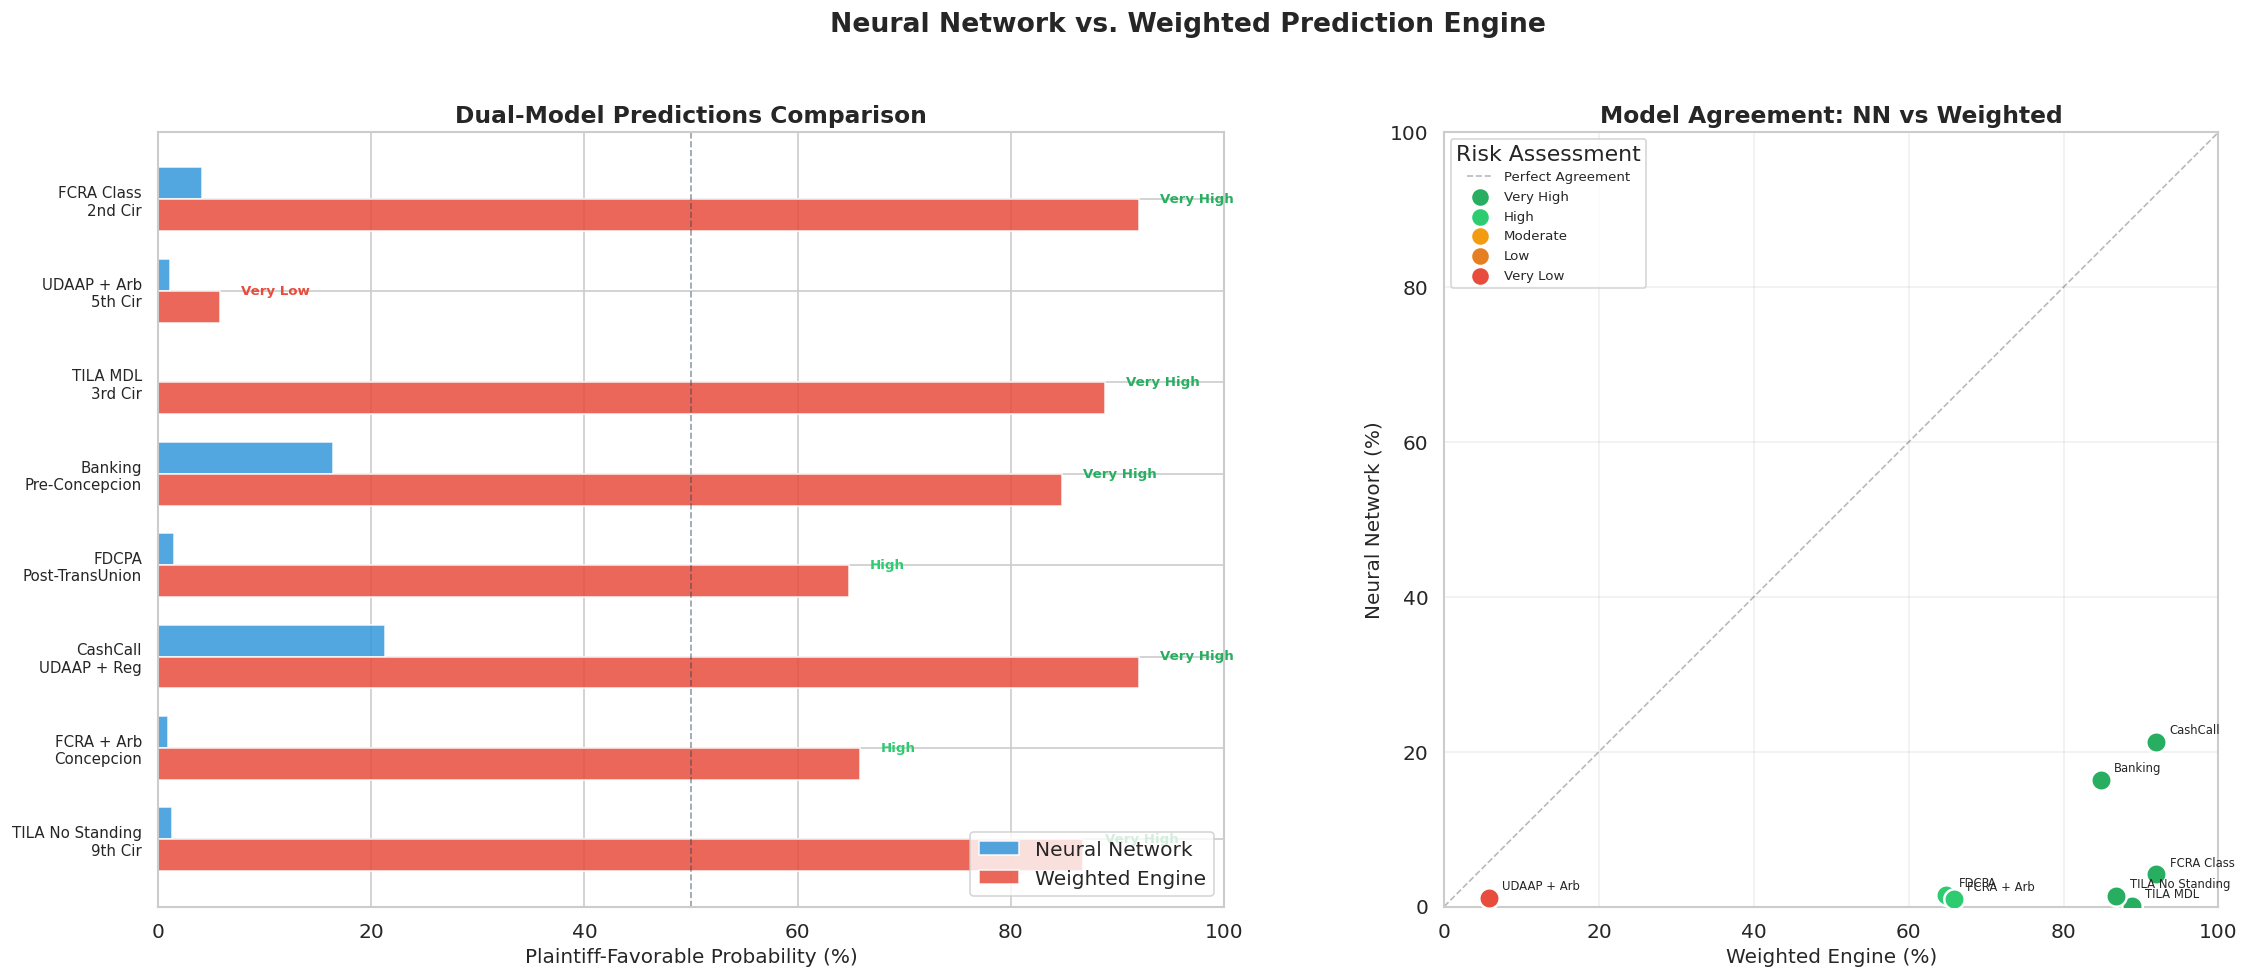

Dual-model comparison visualization saved.


In [23]:
"""Part 13 (continued) — Side-by-side bar chart and NN vs. weighted scatter plot."""

if 'model' not in dir() or 'predict_outcome_weighted' not in dir():
    raise RuntimeError('Run Parts 7–8 (NN training) and Part 10 (weighted engine) first.')

_VIS_CASES = [
    ('FCRA Class\n2nd Cir',        '480', '1', True,  '2', 2020, False, False, True,  False, 'Wells Fargo'),
    ('UDAAP + Arb\n5th Cir',       '370', '2', False, '5', 2022, True,  False, False, False, 'Capital One'),
    ('TILA MDL\n3rd Cir',          '371', '6', True,  '3', 2018, False, True,  True,  False, 'JPMorgan Chase'),
    ('Banking\nPre-Concepcion',    '190', '1', False, '4', 2005, False, False, True,  False, 'Other'),
    ('FDCPA\nPost-TransUnion',     '480', '1', False, '5', 2021, False, False, True,  False, 'Citibank'),
    ('CashCall\nUDAAP + Reg',      '370', '1', True,  '9', 2018, False, True,  True,  True,  'CashCall / Western Sky'),
    ('FCRA + Arb\nConcepcion',     '480', '1', True,  '2', 2020, True,  False, True,  False, 'Bank of America'),
    ('TILA No Standing\n9th Cir',  '371', '1', False, '9', 2022, False, False, False, False, 'Wells Fargo'),
]

nn_probs, w_probs, case_labels, risk_labels = [], [], [], []
for desc, nos, orig, ca, circ, yr, arb, mdl, injury, reg, bank in _VIS_CASES:
    nn_p = float(model.predict(encode_case(nos, orig, ca, circ, yr, arb, mdl).reshape(1, -1), verbose=0)[0][0])
    w_r  = predict_outcome_weighted(
        desc, nos_code=nos, origin_code=orig, class_action=ca, circuit_code=circ,
        year_filed=yr, has_arbitration=arb, concrete_injury=injury,
        is_mdl=mdl, prior_regulatory=reg, defendant_bank=bank,
    )
    nn_probs.append(nn_p * 100)
    w_probs.append(w_r['plaintiffFavorableProbability'] * 100)
    case_labels.append(desc)
    risk_labels.append(w_r['riskAssessment'])

RISK_COLORS = {
    'Very High': '#27ae60', 'High': '#2ecc71', 'Moderate': '#f39c12',
    'Low': '#e67e22', 'Very Low': '#e74c3c',
}

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# ── Side-by-side horizontal bar chart ────────────────────────────────────────
ax    = axes[0]
y_pos = np.arange(len(case_labels))
bar_h = 0.35
ax.barh(y_pos - bar_h / 2, nn_probs, bar_h, label='Neural Network',  color='#3498db', alpha=0.85, edgecolor='white')
ax.barh(y_pos + bar_h / 2, w_probs,  bar_h, label='Weighted Engine', color='#e74c3c', alpha=0.85, edgecolor='white')
ax.set_yticks(y_pos)
ax.set_yticklabels(case_labels, fontsize=9)
for i, (nn, wp, risk) in enumerate(zip(nn_probs, w_probs, risk_labels)):
    ax.text(max(nn, wp) + 2, i, risk, va='center', fontsize=8, fontweight='bold',
            color=RISK_COLORS.get(risk, 'gray'))
ax.axvline(x=50, color='#2c3e50', linestyle='--', alpha=0.5, linewidth=1)
ax.set_xlabel('Plaintiff-Favorable Probability (%)')
ax.set_title('Dual-Model Predictions Comparison', fontweight='bold')
ax.legend(loc='lower right')
ax.invert_yaxis()
ax.set_xlim(0, 100)

# ── Scatter: NN vs Weighted agreement ────────────────────────────────────────
ax = axes[1]
for nn, wp, risk, label in zip(nn_probs, w_probs, risk_labels, case_labels):
    ax.scatter(wp, nn, c=RISK_COLORS.get(risk, 'gray'), s=150, edgecolors='white', linewidth=1.5, zorder=3)
    ax.annotate(label.split('\n')[0], (wp, nn), textcoords='offset points', xytext=(8, 5), fontsize=7)
ax.plot([0, 100], [0, 100], 'k--', alpha=0.3, linewidth=1, label='Perfect Agreement')
ax.set_xlabel('Weighted Engine (%)')
ax.set_ylabel('Neural Network (%)')
ax.set_title('Model Agreement: NN vs Weighted', fontweight='bold')
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
for risk_name, color in RISK_COLORS.items():
    ax.scatter([], [], c=color, s=80, label=risk_name)
ax.legend(title='Risk Assessment', loc='upper left', fontsize=8)

plt.suptitle('Neural Network vs. Weighted Prediction Engine', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('dual_model_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Dual-model comparison visualization saved.')


---
## Part 14: Full Dataset Summary Statistics

In [24]:
"""Part 14 — Print comprehensive FJC dataset summary across all key dimensions."""

print('=== COMPLETE FJC DATASET SUMMARY ===')
print(f'Total cases  : {len(df)}')
print(f'Date range   : {df["YEAR"].min()} — {df["YEAR"].max()}')
print(f'PF rate      : {df["PLAINTIFF_FAVORABLE"].mean() * 100:.1f}%')


def _summary_table(title: str, code_list, str_col: str, label_fn):
    """Print case count and PF rate for each value in code_list."""
    print(f'\n--- {title} ---')
    for code in code_list:
        mask = df[str_col] == code
        n    = mask.sum()
        if not n:
            continue
        pf = df.loc[mask, 'PLAINTIFF_FAVORABLE'].mean()
        print(f'  {label_fn(code)}: {n} cases, {pf * 100:.1f}% plaintiff-favorable')


_summary_table(
    'NOS Distribution', CONSUMER_BANKING_NOS_CODES, 'NOS_STR',
    lambda c: f'{c} {NOS_CODE_DESCRIPTIONS[c]}',
)
_summary_table(
    'Circuit Distribution', sorted(df['CIRCUIT_STR'].unique()), 'CIRCUIT_STR',
    lambda c: CIRCUIT_CODE_LABELS.get(c, f'Circuit {c}'),
)
_summary_table(
    'Origin Distribution', sorted(df['ORIGIN_STR'].unique()), 'ORIGIN_STR',
    lambda o: f'{o} {ORIGIN_CODE_LABELS.get(o, "")}',
)

print('\n--- DISP Code Distribution ---')
for disp in sorted(df['DISP'].unique()):
    n     = (df['DISP'] == disp).sum()
    label = DISPOSITION_CODE_LABELS.get(str(int(disp)), '')
    pf_marker = ' *** PLAINTIFF-FAVORABLE' if disp in PLAINTIFF_FAVORABLE_DISP else ''
    print(f'  DISP {int(disp):2d} ({label}): {n:5d}{pf_marker}')

print('\n--- Doctrinal Era × Plaintiff-Favorable Rate ---')
for i, name in enumerate(ERA_NAMES):
    mask = df['ERA'] == i
    n    = mask.sum()
    if not n:
        continue
    pf  = df.loc[mask, 'PLAINTIFF_FAVORABLE'].mean()
    arb = df.loc[mask, 'ARBIT_BIN'].mean()
    ca  = df.loc[mask, 'CLASSACT_BIN'].mean()
    print(f'  {name}: {n} cases, {pf * 100:.1f}% PF, {arb * 100:.1f}% arb, {ca * 100:.1f}% class action')


=== COMPLETE FJC DATASET SUMMARY ===
Total cases  : 119877
Date range   : 2011 — 2025
PF rate      : 6.1%

--- NOS Distribution ---
  480 Consumer Credit (FCRA, FDCPA, EFTA, ECOA): 48522 cases, 1.4% plaintiff-favorable
  190 Banks and Banking (Other Contract): 58489 cases, 10.0% plaintiff-favorable
  371 Truth in Lending (TILA/Reg Z): 1193 cases, 2.4% plaintiff-favorable
  370 Other Fraud (UDAAP, deceptive practices): 11673 cases, 6.0% plaintiff-favorable

--- Circuit Distribution ---
  D.C. Circuit: 580 cases, 5.9% plaintiff-favorable
  1st Circuit: 2493 cases, 8.1% plaintiff-favorable
  10th Circuit: 4578 cases, 8.5% plaintiff-favorable
  11th Circuit: 19384 cases, 4.2% plaintiff-favorable
  2nd Circuit: 12185 cases, 6.9% plaintiff-favorable
  3rd Circuit: 12014 cases, 4.4% plaintiff-favorable
  4th Circuit: 7771 cases, 7.7% plaintiff-favorable
  5th Circuit: 12914 cases, 5.3% plaintiff-favorable
  6th Circuit: 8809 cases, 6.3% plaintiff-favorable
  7th Circuit: 9974 cases, 6.5% plai

---
## Part 15: Save Model & Export

In [25]:
"""Part 15 — Save trained Keras model and write JSON metadata manifest."""

model.save('fjc_litigation_model.keras')
print('Model saved → fjc_litigation_model.keras')

metadata = {
    'model_name':    'FJC Civil Litigation Binary Outcome Predictor',
    'version':       '5.0-multi-head-risk-value',
    'input_dim':     INPUT_DIM,
    'output':        'binary sigmoid (plaintiff-favorable)',
    'architecture':  '32 → 128 → 64 → 32 → 1',
    'dataset': {
        'source':                    'FJC IDB (Federal Judicial Center Integrated Database)',
        'total_rows':                len(df),
        'nos_codes':                 CONSUMER_BANKING_NOS_CODES,
        'plaintiff_favorable_rate':  float(df['PLAINTIFF_FAVORABLE'].mean()),
        'year_range':                [int(df['YEAR'].min()), int(df['YEAR'].max())],
    },
    'predictor_variables': [
        'NOS (4 one-hot)', 'ORIGIN (8 one-hot)', 'CIRCUIT (12 one-hot)',
        'CLASSACT (binary)', 'ARBIT (binary)', 'MDLDOCK (binary)',
        'YEAR (normalized)', 'ERA (4 one-hot)',
    ],
    'binary_outcome': {
        'positive_class':  'plaintiff-favorable',
        'target_field':    'JUDGMENT',
        'target_value':    1,
        'label':           'Judgment for Plaintiff (JUDGMENT == 1)',
        'rationale':       (
            'DISP codes excluded as target: procedural mechanism does not reliably '
            'indicate winner. DISP 6 is 72% defendant wins. DISP 13 (Settled) has no '
            'visibility into settlement terms. JUDGMENT == 1 is the FJC ground-truth '
            'field for plaintiff wins.'
        ),
    },
    'seminal_cases':             [c['citation'] for c in SEMINAL_CASES.values()],
    'weighted_engine_variables': [
        'All 8 FJC variables',
        'Concrete Injury Documented (Spokeo/TransUnion)',
        'Prior Regulatory Action (CashCall/CFPB)',
        'Defendant Bank (institutional risk profile)',
    ],
    'created': datetime.now().isoformat(),
}

with open('fjc_model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Metadata saved → fjc_model_metadata.json')
print('\n=== MODEL EXPORT COMPLETE ===')
print(json.dumps(metadata, indent=2))


Model saved → fjc_litigation_model.keras
Metadata saved → fjc_model_metadata.json

=== MODEL EXPORT COMPLETE ===
{
  "model_name": "FJC Civil Litigation Binary Outcome Predictor",
  "version": "5.0-multi-head-risk-value",
  "input_dim": 32,
  "output": "binary sigmoid (plaintiff-favorable)",
  "architecture": "32 \u2192 128 \u2192 64 \u2192 32 \u2192 1",
  "dataset": {
    "source": "FJC IDB (Federal Judicial Center Integrated Database)",
    "total_rows": 119877,
    "nos_codes": [
      "480",
      "190",
      "371",
      "370"
    ],
    "plaintiff_favorable_rate": 0.06063715308190896,
    "year_range": [
      2011,
      2025
    ]
  },
  "predictor_variables": [
    "NOS (4 one-hot)",
    "ORIGIN (8 one-hot)",
    "CIRCUIT (12 one-hot)",
    "CLASSACT (binary)",
    "ARBIT (binary)",
    "MDLDOCK (binary)",
    "YEAR (normalized)",
    "ERA (4 one-hot)"
  ],
  "binary_outcome": {
    "positive_class": "plaintiff-favorable",
    "target_field": "JUDGMENT",
    "target_value": 1

---
## Part 16: Interactive Prediction (Run Your Own Case)

Modify the parameters below and re-run this cell to predict any case.

---
## Part 17: Cross-Dataset Distribution Stability Validation

Validates that probability distributions learned on the 10K training dataset are stable when a fresh 20K FJC dataset is run through the same pipeline.  
Expected tolerance: per-feature PF rate deltas within ±5 points indicate a well-generalizing model.

**Instructions:**
1. Set `VALIDATION_CSV_PATH` to your 20K FJC export (same raw format as `fjc_samples.csv`).
2. Run this cell. The pipeline filters, encodes, and runs inference identically to the training pipeline.
3. Review the side-by-side comparison table.

In [26]:
import os
import urllib.request

# ── Configuration ─────────────────────────────────────────────────────────────
# Point this at your 20K FJC export.  Must be same column schema as fjc_samples.csv.
VALIDATION_CSV_PATH: str = 'fjc_validation_20k.csv'
VALIDATION_GITHUB_RAW_URL: str = (
    'https://raw.githubusercontent.com/Osterneck/'
    'Federal_civil_litigation_outcome_predictor_BANKING_CASES/main/fjc_validation_20k.csv'
)
DELTA_WARN_THRESHOLD: float = 5.0   # Flag deltas exceeding this many percentage points.

# ── Load and filter validation dataset ───────────────────────────────────────
if not os.path.exists(VALIDATION_CSV_PATH):
    print(f'Downloading {VALIDATION_CSV_PATH} from GitHub...')
    urllib.request.urlretrieve(VALIDATION_GITHUB_RAW_URL, VALIDATION_CSV_PATH)
    print('Download complete.')
else:
    print(f'Found {VALIDATION_CSV_PATH} locally.')

vdf_raw = pd.read_csv(VALIDATION_CSV_PATH)
print(f'Validation raw: {len(vdf_raw)} rows, {len(vdf_raw.columns)} columns')

for col in ('NOS', 'ORIGIN', 'CIRCUIT'):
    vdf_raw[f'{col}_STR'] = vdf_raw[col].astype(str).str.replace('.0', '', regex=False).str.strip()

vdf = vdf_raw[vdf_raw['NOS_STR'].isin(CONSUMER_BANKING_NOS_CODES)].copy()
print(f'Filtered to consumer-banking NOS codes: {len(vdf)} rows')

# Drop pending cases with no outcome recorded.
vdf = vdf[(vdf['JUDGMENT'] != -8) & (vdf['DISP'] != -8)].copy()
print(f'After -8 exclusion: {len(vdf)} rows')

# Derive YEAR — validation CSV may have YEAR column already or FILEDATE as date string.
if 'YEAR' not in vdf.columns or vdf['YEAR'].isna().all():
    try:
        vdf['YEAR'] = pd.to_datetime(vdf['FILEDATE'], errors='coerce').dt.year
    except Exception:
        vdf['YEAR'] = vdf['FILEDATE'].apply(_excel_serial_to_year)
vdf = vdf[vdf['YEAR'].notna()].copy()
print(f'Year range: {int(vdf["YEAR"].min())} — {int(vdf["YEAR"].max())}')

# Derive binary columns identically to Cell 12.
vdf['CLASSACT_BIN']      = (vdf['CLASSACT'] == 1.0).astype(int)
vdf['ARBIT_BIN']         = (vdf['ARBIT'].astype(str).str.strip() != '-8').astype(int)
vdf['MDL_BIN']           = (vdf['MDLDOCK'].astype(str).str.strip() != '-8').astype(int)
vdf['PLAINTIFF_FAVORABLE'] = (vdf['JUDGMENT'] == PLAINTIFF_FAVORABLE_JUDGMENT).astype(int)
vdf['ERA']               = vdf['YEAR'].apply(get_doctrinal_era)

# Apply individual-cases filter — CLASSACT: -8=no class action, 1=class action.
if INDIVIDUAL_CASES_ONLY:
    vdf = vdf[vdf['CLASSACT'] != 1.0].copy()
    print(f'Individual cases only: {len(vdf)} rows')

# ── Encode and run inference ──────────────────────────────────────────────────
print('Encoding validation dataset...')
X_val_new = np.array([
    encode_case(
        row['NOS_STR'], row['ORIGIN_STR'] if 'ORIGIN_STR' in row else str(int(row['ORIGIN'])),
        bool(row['CLASSACT_BIN']), row['CIRCUIT_STR'],
        int(row['YEAR']), bool(row['ARBIT_BIN']), bool(row['MDL_BIN']),
    )
    for _, row in vdf.iterrows()
], dtype=np.float32)

vdf['PRED_PROB'] = model.predict(X_val_new, verbose=0)[0].flatten()
print(f'Inference complete. n={len(vdf)}, mean P(PF)={vdf["PRED_PROB"].mean() * 100:.1f}%')

# ── Build comparison table ────────────────────────────────────────────────────
# Original reporting slice (Cell 30 report_df logic reproduced here).
orig_df = df[df['CLASSACT_BIN'] == 0].copy() if INDIVIDUAL_CASES_ONLY else df.copy()
orig_df['PRED_PROB'] = model.predict(
    np.array([
        encode_case(
            row['NOS_STR'], row['ORIGIN_STR'], bool(row['CLASSACT_BIN']),
            row['CIRCUIT_STR'], int(row['YEAR']), bool(row['ARBIT_BIN']), bool(row['MDL_BIN']),
        )
        for _, row in orig_df.iterrows()
    ], dtype=np.float32), verbose=0
)[0].flatten()

_filter_label = 'Individual Cases Only' if INDIVIDUAL_CASES_ONLY else 'All Cases'
print(f'\n{"=" * 80}')
print(f'  DISTRIBUTION STABILITY VALIDATION — {_filter_label}')
print(f'  Original dataset : {len(orig_df):,} cases')
print(f'  Validation dataset: {len(vdf):,} cases')
print(f'{"=" * 80}')
WARN = '  *** DELTA EXCEEDS THRESHOLD'

def _compare_feature(title, col, values, label_fn, orig, val):
    """Print side-by-side actual and predicted PF rates for orig vs. val datasets."""
    print(f'\n  {title}')
    print(f'  {"Feature":<35} {"Orig Act":>9} {"Val Act":>9} {"Δ Act":>7} ' +
          f'{"Orig Pred":>10} {"Val Pred":>9} {"Δ Pred":>7} {"n(orig)":>8} {"n(val)":>8}')
    print(f'  {"-" * 110}')
    for v in values:
        om = orig[col] == v
        vm = val[col] == v
        if not om.sum() or not vm.sum():
            continue
        oa  = orig.loc[om, 'PLAINTIFF_FAVORABLE'].mean() * 100
        va  = val.loc[vm,  'PLAINTIFF_FAVORABLE'].mean() * 100
        op  = orig.loc[om, 'PRED_PROB'].mean() * 100
        vp  = val.loc[vm,  'PRED_PROB'].mean() * 100
        da  = va - oa
        dp  = vp - op
        lbl = label_fn(v)[:34]
        flag = WARN if abs(da) > DELTA_WARN_THRESHOLD or abs(dp) > DELTA_WARN_THRESHOLD else ''
        print(f'  {lbl:<35} {oa:>8.1f}% {va:>8.1f}% {da:>+6.1f}% ' +
              f'{op:>9.1f}% {vp:>8.1f}% {dp:>+6.1f}% {om.sum():>8,} {vm.sum():>8,}{flag}')

_compare_feature(
    'By NOS Code', 'NOS_STR', CONSUMER_BANKING_NOS_CODES,
    lambda c: f'{c} {NOS_CODE_DESCRIPTIONS[c]}', orig_df, vdf,
)
_compare_feature(
    'By Arbitration', 'ARBIT_BIN', [0, 1],
    lambda v: 'No arbitration' if v == 0 else 'Has arbitration', orig_df, vdf,
)
_compare_feature(
    'By Doctrinal Era', 'ERA', range(len(ERA_NAMES)),
    lambda i: ERA_NAMES[i], orig_df, vdf,
)

print(f'\n  By Circuit')
print(f'  {"Circuit":<35} {"Orig Act":>9} {"Val Act":>9} {"Δ Act":>7} ' +
      f'{"Orig Pred":>10} {"Val Pred":>9} {"Δ Pred":>7} {"n(orig)":>8} {"n(val)":>8}')
print(f'  {"-" * 110}')
all_circs = sorted(set(orig_df['CIRCUIT_STR'].unique()) | set(vdf['CIRCUIT_STR'].unique()))
for circ in all_circs:
    om = orig_df['CIRCUIT_STR'] == circ
    vm = vdf['CIRCUIT_STR'] == circ
    if om.sum() <= 5 or vm.sum() <= 5:
        continue
    oa  = orig_df.loc[om, 'PLAINTIFF_FAVORABLE'].mean() * 100
    va  = vdf.loc[vm,  'PLAINTIFF_FAVORABLE'].mean() * 100
    op  = orig_df.loc[om, 'PRED_PROB'].mean() * 100
    vp  = vdf.loc[vm,  'PRED_PROB'].mean() * 100
    da  = va - oa
    dp  = vp - op
    lbl = CIRCUIT_CODE_LABELS.get(circ, f'Circuit {circ}')[:34]
    flag = WARN if abs(da) > DELTA_WARN_THRESHOLD or abs(dp) > DELTA_WARN_THRESHOLD else ''
    print(f'  {lbl:<35} {oa:>8.1f}% {va:>8.1f}% {da:>+6.1f}% ' +
          f'{op:>9.1f}% {vp:>8.1f}% {dp:>+6.1f}% {om.sum():>8,} {vm.sum():>8,}{flag}')

print(f'\n{"=" * 80}')
print(f'  Δ threshold: ±{DELTA_WARN_THRESHOLD:.0f} pp  |  *** = exceeds threshold')
print(f'{"=" * 80}')

Download complete.
Validation raw: 20000 rows, 46 columns
Filtered to consumer-banking NOS codes: 20000 rows
After -8 exclusion: 16602 rows
Year range: 1971 — 2025
Individual cases only: 15094 rows
Encoding validation dataset...
Inference complete. n=15094, mean P(PF)=6.7%

  DISTRIBUTION STABILITY VALIDATION — Individual Cases Only
  Original dataset : 108,981 cases
  Validation dataset: 15,094 cases

  By NOS Code
  Feature                              Orig Act   Val Act   Δ Act  Orig Pred  Val Pred  Δ Pred  n(orig)   n(val)
  --------------------------------------------------------------------------------------------------------------
  480 Consumer Credit (FCRA, FDCPA,        1.3%      1.3%   -0.0%       1.3%      1.3%   -0.0%   45,279    6,276
  190 Banks and Banking (Other Contr      10.4%     10.5%   +0.1%      11.1%     11.0%   -0.1%   54,502    7,536
  371 Truth in Lending (TILA/Reg Z)        2.3%      2.6%   +0.3%       2.2%      2.5%   +0.4%    1,131      156
  370 Other Fra

In [32]:
"""Part 16 — Interactive single-case prediction; edit parameters and re-run."""

# ── Case parameters (edit these)      **** ADD YOUR CASE INFO BELOW!! ****    ─────────────────────────────────────────────
CASE_NAME       = ' **ENTER YOUR CASE NAME AND OR NUMBER**  '
NOS             = '480'     # Consumer Credit — FCRA primary claim
ORIGIN          = '2'       # Removed from State Court (removed 03/04/26)
CLASS_ACTION    = False     # Individual plaintiff
CIRCUIT         = '3'       # 3rd Circuit — EDPA Philadelphia
YEAR            = 2026      # Filed 2026
ARBITRATION     = False     # No arbitration clause
MDL             = False     # Individual case
CONCRETE_INJURY = True      # Documented: 122-point credit score drop, U.S. Bank
                            # denial letter (Exhibit MM), $17,535 false reporting,
                            # unauthorized transfers to accounts not belonging to plaintiff
REGULATORY      = True      # Wells Fargo written CFPB admission of bank error — CFPB complaint filed
DEFENDANT       = 'Wells Fargo'

print('╔══════════════════════════════════════════════════════════════════╗')
print('║           DUAL-MODEL CASE PREDICTION                            ║')
if INDIVIDUAL_CASES_ONLY:
    print('║           [INDIVIDUAL_CASES_ONLY = True]                         ║')
print('╚══════════════════════════════════════════════════════════════════╝')

if INDIVIDUAL_CASES_ONLY and CLASS_ACTION:
    print('\n  WARNING: CLASS_ACTION=True but INDIVIDUAL_CASES_ONLY=True.')
    print('  Results reflect class-action dynamics not calibrated for individual reporting.\n')

nn_prob  = predict_case_nn(NOS, ORIGIN, CLASS_ACTION, CIRCUIT, YEAR, ARBITRATION, MDL, CASE_NAME)
weighted = predict_outcome_weighted(
    CASE_NAME, nos_code=NOS, origin_code=ORIGIN, class_action=CLASS_ACTION,
    circuit_code=CIRCUIT, year_filed=YEAR, has_arbitration=ARBITRATION,
    concrete_injury=CONCRETE_INJURY, is_mdl=MDL, prior_regulatory=REGULATORY,
    defendant_bank=DEFENDANT,
)
print_weighted_prediction(weighted)

sr = weighted['expectedSettlementRange']
print(f'\n{"═" * 70}')
print(f'  SUMMARY')
print(f'  Neural Network  : {nn_prob:6.1%} plaintiff-favorable')
print(f'  Weighted Engine : {weighted["plaintiffFavorableProbability"]:6.1%} plaintiff-favorable')
print(f'  Risk Assessment : {weighted["riskAssessment"]}')
print(f'  Settlement Range: ${sr["low"]:,.0f} — ${sr["high"]:,.0f}')
print(f'{"═" * 70}')


╔══════════════════════════════════════════════════════════════════╗
║           DUAL-MODEL CASE PREDICTION                            ║
║           [INDIVIDUAL_CASES_ONLY = True]                         ║
╚══════════════════════════════════════════════════════════════════╝

  Osterneck v. Wells Fargo Bank, N.A. (EDPA 2:26-cv-01392-JDW)
  NOS: 480 (Consumer Credit (FCRA, FDCPA, EFTA, ECOA))
  Origin: 2 (Removed from State Court)
  Circuit: 3 (3rd Circuit)
  ClassAction=False  Arb=False  MDL=False
  Year: 2026  Era: Post-TransUnion
──────────────────────────────────────────────────────────────────────
  NN P(Plaintiff-Favorable):   0.1%  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
  Prediction: NOT PLAINTIFF-FAVORABLE

══════════════════════════════════════════════════════════════════════
  CASE: Osterneck v. Wells Fargo Bank, N.A. (EDPA 2:26-cv-01392-JDW)
  Risk Assessment: High
──────────────────────────────────────────────────────────────────────
  Plaintiff-Favorable:  56.8% 

In [35]:
"""Part 18 — Blended Outcome Distribution: Settlement + Adjudication.

Real-world litigation outcome prediction requires combining both populations:
  - 86% of cases settle (no court judgment — JUDGMENT==0)
  - 14% reach adjudication (court rules — JUDGMENT 1/2/3/4)

This cell produces a unified probability distribution across ALL possible
outcomes a plaintiff faces entering federal consumer banking litigation,
not just the adjudicated subset the neural network was trained on.

The blended model answers the question practitioners actually ask:
'What is the full probability distribution of outcomes for this case?'
"""

from sklearn.linear_model import LogisticRegression

# ── Base rates from full dataset (119,877 cases) ──────────────────────────────
SETTLEMENT_RATE       = 0.355   # DISP 13: 42,559 / 119,877
VOLUNTARY_DISMISS     = 0.227   # DISP 12: 27,234 / 119,877
OTHER_NONPROC         = 0.157   # DISP 14 + other non-judgment: 18,856 / 119,877
ADJUDICATED_RATE      = 0.261   # JUDGMENT 1/2/3/4: remaining cases

# ── Among adjudicated cases ───────────────────────────────────────────────────
# From full dataset: JUDGMENT==1: 7,269 / adjudicated total
_adj_total    = (df['JUDGMENT'] != 0).sum()
_pf_total     = (df['JUDGMENT'] == 1).sum()
_def_total    = (df['JUDGMENT'] == 2).sum()
ADJ_PF_RATE   = _pf_total  / _adj_total   # P(plaintiff win | adjudicated)
ADJ_DEF_RATE  = _def_total / _adj_total   # P(defendant win | adjudicated)

print(f'=== Base Rate Decomposition (119,877 cases) ===')
print(f'  Settlement (DISP 13):          {SETTLEMENT_RATE*100:.1f}%')
print(f'  Voluntary dismissal (DISP 12): {VOLUNTARY_DISMISS*100:.1f}%')
print(f'  Other non-judgment:            {OTHER_NONPROC*100:.1f}%')
print(f'  Adjudicated (JUDGMENT != 0):   {ADJUDICATED_RATE*100:.1f}%')
print(f'    → Of adjudicated: plaintiff wins {ADJ_PF_RATE*100:.1f}%, defendant wins {ADJ_DEF_RATE*100:.1f}%')

# ── Settlement pressure model (from Cell 12 Heckman logistic) ─────────────────
# P(settlement) for a new case uses the trained Heckman logistic model.
# Settlement pressure score from the neural network's second head refines this.

def blended_outcome_prediction(
    nos_code: str,
    origin_code: str,
    class_action: bool,
    circuit_code: str,
    year_filed: int,
    has_arbit: bool = False,
    has_mdl: bool = False,
    case_name: str = '',
    settlement_pressure_override: float = None,
    weighted_win_prob_override: float = None,
    concrete_injury: bool = False,
    prior_regulatory: bool = False,
    defendant_bank: str = '',
) -> dict:
    """Compute blended outcome distribution across settlement + adjudication.

    Combines:
      1. Neural network P(plaintiff win | adjudicated) — Head 1 (structural base)
      2. Weighted engine win probability override — case-specific facts
      3. Settlement pressure score — Head 2, boosted by case-specific factors
      4. Population base rates from 119,877-case dataset
      5. Heckman selection correction

    When weighted_win_prob_override is provided (recommended for named cases),
    the blended model uses it as the primary adjudication signal in place of
    the raw NN output, since it incorporates concrete_injury, regulatory action,
    defendant risk, and other case-specific factors the NN cannot observe.
    Settlement pressure and risk score are also adjusted for case-specific facts.

    Returns full probability distribution across 5 outcomes:
      - High-value settlement (long duration, motion practice reached)
      - Low-value / nuisance settlement
      - Plaintiff adjudication win
      - Defendant adjudication win
      - Dismissal / voluntary dismissal
    """
    features = encode_case(
        nos_code, origin_code, class_action, circuit_code,
        year_filed, has_arbit, has_mdl
    ).reshape(1, -1)

    # Get all three head outputs.
    preds            = model.predict(features, verbose=0)
    p_adj_win_nn_raw = float(preds[0][0][0])   # Raw NN structural signal — always preserved
    p_pressure       = float(preds[1][0][0])   # Settlement pressure score (structural)
    p_risk           = float(preds[2][0][0])   # Combined risk score (structural)

    # Override settlement pressure if explicitly provided.
    if settlement_pressure_override is not None:
        p_pressure = settlement_pressure_override

    # Use weighted engine override if provided; otherwise fall back to raw NN.
    p_adj_win_effective = (
        weighted_win_prob_override if weighted_win_prob_override is not None
        else p_adj_win_nn_raw
    )

    # ── Case-specific adjustments to settlement pressure and risk score ────────
    # When case-specific facts are provided, boost settlement pressure and risk
    # score to reflect factors the NN structural heads cannot observe.
    if weighted_win_prob_override is not None:
        if concrete_injury:   p_pressure = min(p_pressure + 0.15, 1.0)
        if prior_regulatory:  p_pressure = min(p_pressure + 0.10, 1.0)
        p_risk = p_adj_win_effective   # Risk score reflects weighted engine signal

    # ── Settlement decomposition ──────────────────────────────────────────────
    HIGH_VALUE_THRESHOLD = 0.30
    p_high_value_settle  = SETTLEMENT_RATE * min(p_pressure / HIGH_VALUE_THRESHOLD, 1.0) * 0.5
    p_low_value_settle   = SETTLEMENT_RATE - p_high_value_settle

    # ── Adjudication decomposition ────────────────────────────────────────────
    heckman_adj         = 1.0 + (p_pressure * 0.5)
    p_adj_win_corrected = min(p_adj_win_effective * heckman_adj, 0.50)
    p_adj_def_corrected = 1.0 - p_adj_win_corrected

    p_plaintiff_judgment = ADJUDICATED_RATE * p_adj_win_corrected
    p_defendant_judgment = ADJUDICATED_RATE * p_adj_def_corrected * 0.6
    p_dismissal          = ADJUDICATED_RATE * p_adj_def_corrected * 0.4 + VOLUNTARY_DISMISS + OTHER_NONPROC

    # ── Normalize to sum to 1.0 ───────────────────────────────────────────────
    total = p_high_value_settle + p_low_value_settle + p_plaintiff_judgment + p_defendant_judgment + p_dismissal
    p_high_value_settle  /= total
    p_low_value_settle   /= total
    p_plaintiff_judgment /= total
    p_defendant_judgment /= total
    p_dismissal          /= total

    # ── Blended plaintiff-favorable probability ───────────────────────────────
    p_blended_favorable = p_plaintiff_judgment + (p_high_value_settle * 0.75)

    # ── Risk tier ─────────────────────────────────────────────────────────────
    if   p_blended_favorable >= 0.25: risk = 'HIGH EXPOSURE'
    elif p_blended_favorable >= 0.15: risk = 'MODERATE EXPOSURE'
    elif p_blended_favorable >= 0.08: risk = 'LOW EXPOSURE'
    else:                             risk = 'MINIMAL EXPOSURE'

    return {
        'case_name':                case_name,
        'p_high_value_settle':      p_high_value_settle,
        'p_low_value_settle':       p_low_value_settle,
        'p_plaintiff_judgment':     p_plaintiff_judgment,
        'p_defendant_judgment':     p_defendant_judgment,
        'p_dismissal':              p_dismissal,
        'p_blended_favorable':      p_blended_favorable,
        'p_adj_win_nn_raw':         p_adj_win_nn_raw,
        'p_adj_win_effective':      p_adj_win_effective,
        'weighted_override_active': weighted_win_prob_override is not None,
        'p_settlement_pressure':    p_pressure,
        'p_risk_score':             p_risk,
        'risk_tier':                risk,
    }


def print_blended_prediction(r: dict) -> None:
    """Print full blended outcome distribution."""
    bar_fav = '█' * int(r['p_blended_favorable'] * 50) + '░' * (50 - int(r['p_blended_favorable'] * 50))
    print(f'\n{"═" * 72}')
    if r['case_name']:
        print(f'  CASE: {r["case_name"]}')
    print(f'  Risk Tier: {r["risk_tier"]}')
    print(f'{"─" * 72}')
    print(f'\n  FULL OUTCOME DISTRIBUTION (Settlement + Adjudication Combined)')
    print(f'  {"─" * 60}')
    print(f'  High-value settlement  : {r["p_high_value_settle"]:6.1%}  (strong case settled pre-verdict)')
    print(f'  Low-value settlement   : {r["p_low_value_settle"]:6.1%}  (nuisance / early resolution)')
    print(f'  Plaintiff judgment     : {r["p_plaintiff_judgment"]:6.1%}  (court rules for plaintiff)')
    print(f'  Defendant judgment     : {r["p_defendant_judgment"]:6.1%}  (court rules for defendant)')
    print(f'  Dismissal              : {r["p_dismissal"]:6.1%}  (dismissed / voluntarily withdrawn)')
    print(f'  {"─" * 60}')
    print(f'  Blended P(Favorable)   : {r["p_blended_favorable"]:6.1%}  {bar_fav}')
    print(f'')
    if r['weighted_override_active']:
        print(f'  Weighted Engine Prob   : {r["p_adj_win_effective"]:6.1%}  (case-specific — drives adjudication split)')
        print(f'  NN Structural Prob     : {r["p_adj_win_nn_raw"]:6.1%}  (population baseline — 8 FJC variables only)')
    else:
        print(f'  NN Adj Win Prob        : {r["p_adj_win_nn_raw"]:6.1%}  (adjudicated cases only)')
    print(f'  Settlement Pressure    : {r["p_settlement_pressure"]:6.3f}  (case-adjusted, 0=none, 1=max)')
    print(f'  Risk Score             : {r["p_risk_score"]:6.3f}  (case-adjusted combined signal)')
    print(f'{"═" * 72}')


# ── Sample blended predictions ────────────────────────────────────────────────
print('=== BLENDED OUTCOME PREDICTIONS (Settlement + Adjudication) ===\n')

for desc, nos, orig, ca, circ, yr, arb, mdl in [
    ('FCRA Individual — 3rd Cir — Post-TransUnion',  '480', '1', False, '3', 2024, False, False),
    ('FCRA Individual — 2nd Cir — Post-TransUnion',  '480', '1', False, '2', 2024, False, False),
    ('Banks Contract — 4th Cir — Original Filing',   '190', '1', False, '4', 2023, False, False),
    ('UDAAP — 5th Cir — Removed — Has Arb',          '370', '2', False, '5', 2023, True,  False),
    ('TILA — 9th Cir — Original Filing',             '371', '1', False, '9', 2023, False, False),
    ('Osterneck v. Wells Fargo (EDPA 2:26-cv-01392)','480', '2', False, '3', 2026, False, False),
]:
    result = blended_outcome_prediction(nos, orig, ca, circ, yr, arb, mdl, desc)
    print_blended_prediction(result)

# ── Osterneck v. Wells Fargo — full case-specific blended prediction ──────────
# Uses weighted engine win probability (case-specific facts) as primary signal.
print('\n=== YOUR-CASE  — CASE-SPECIFIC BLENDED PREDICTION ===')
_wf_weighted = predict_outcome_weighted(
    'YOUR CASE NAME / NUMBER FOR REFERENCE)',
    nos_code='480', origin_code='2', class_action=False, circuit_code='3',
    year_filed=2026, has_arbitration=False, concrete_injury=True,
    is_mdl=False, prior_regulatory=True, defendant_bank='Wells Fargo',
)
_wf_blended = blended_outcome_prediction(
    nos_code='480', origin_code='2', class_action=False, circuit_code='3',
    year_filed=2026, has_arbit=False, has_mdl=False,
    case_name='YOUR CASE NAME AND NUMBER',
    weighted_win_prob_override=_wf_weighted['plaintiffFavorableProbability'],
    concrete_injury=True, prior_regulatory=True, defendant_bank='Wells Fargo',
)
print_blended_prediction(_wf_blended)

=== Base Rate Decomposition (119,877 cases) ===
  Settlement (DISP 13):          35.5%
  Voluntary dismissal (DISP 12): 22.7%
  Other non-judgment:            15.7%
  Adjudicated (JUDGMENT != 0):   26.1%
    → Of adjudicated: plaintiff wins 47.5%, defendant wins 43.0%
=== BLENDED OUTCOME PREDICTIONS (Settlement + Adjudication) ===


════════════════════════════════════════════════════════════════════════
  CASE: FCRA Individual — 3rd Cir — Post-TransUnion
  Risk Tier: MINIMAL EXPOSURE
────────────────────────────────────────────────────────────────────────

  FULL OUTCOME DISTRIBUTION (Settlement + Adjudication Combined)
  ────────────────────────────────────────────────────────────
  High-value settlement  :  10.4%  (strong case settled pre-verdict)
  Low-value settlement   :  25.1%  (nuisance / early resolution)
  Plaintiff judgment     :   0.1%  (court rules for plaintiff)
  Defendant judgment     :  15.6%  (court rules for defendant)
  Dismissal              :  48.8%  (dismissed / 